# 08 — OpenCV Telea Restoration

## Purpose

This notebook applies the OpenCV Telea inpainting baseline to eligible controlled restoration cases generated by the preceding dataset notebooks.

The notebook processes:

- the canonical controlled-damage dataset;
- the damage-size sensitivity dataset;
- the mask-robustness dataset when its canonical metadata is available;
- methodologically eligible synthetic-degradation cases when Notebook 07 outputs are available.

## Restoration method

The baseline uses OpenCV's implementation of the Telea fast-marching inpainting method with:

- algorithm: `cv2.INPAINT_TELEA`;
- fixed inpainting radius: `3`;
- deterministic, non-learned execution;
- the supplied mask as the restoration target.

OpenCV Telea is used as a fast, reproducible classical baseline. It is not treated as painting-specific, conservation-grade, or capable of recovering historically verified content.

## Mask interpretation

For canonical damage, damage-size, and mask-robustness cases, masks are binary missing-content masks.

For Notebook 07 synthetic-degradation cases, masks are grayscale effect-intensity masks. The restoration wrapper converts every supplied mask to a binary Telea target using OpenCV thresholding:

```python
mask_gray > 127
```

Synthetic-degradation restoration is therefore supplementary and applies only to high-intensity effect regions. It does not imply that Telea is an appropriate physical correction method for stains, fading, dirt, discolouration, blur, or transparency.

## Case identifiers

Each source dataset is normalized into a shared restoration-input schema.

The notebook creates a globally unique source case identifier:

```text
<dataset_name>__<original_case_id>
```

The restoration module then creates:

```text
opencv_telea__<dataset_name>__<source_case_id>
```

This avoids collisions between upstream datasets while preserving the original source case identifier separately.

## Canonical outputs

### Restored dataset

```text
data/
└── processed/
    ├── restored/
    │   └── opencv_telea/
    │       ├── canonical/
    │       ├── damage_size/
    │       ├── mask_robustness/
    │       └── synthetic_degradation/
    └── metadata/
        └── metadata_restored_opencv_telea.csv
```

### Audit and reporting outputs

```text
outputs/
├── 08_opencv_telea/
│   └── opencv_telea_audit.csv
├── figures/
│   └── opencv_telea/
└── reports/
    ├── opencv_telea_manifest.json
    └── opencv_telea_report.md
```

Only two permanent CSV artifacts are written:

```text
metadata_restored_opencv_telea.csv
opencv_telea_audit.csv
```

All intermediate summaries and detailed validation tables remain in memory and are consolidated into the JSON manifest and Markdown report.

In [1]:
from pathlib import Path


def find_project_root(
    start_path: Path | None = None,
) -> Path:
    """Locate the repository root from the current working directory."""
    current_path = (
        Path.cwd()
        if start_path is None
        else Path(start_path)
    ).resolve()

    root_markers = (
        "pyproject.toml",
        ".git",
        "src",
        "notebooks",
    )

    for candidate_path in (
        current_path,
        *current_path.parents,
    ):
        marker_count = sum(
            (candidate_path / marker_name).exists()
            for marker_name in root_markers
        )

        if (
            (candidate_path / "src").is_dir()
            and
            (candidate_path / "notebooks").is_dir()
            and
            marker_count >= 2
        ):
            return candidate_path

    raise FileNotFoundError(
        "Could not locate the project root. "
        "Run the notebook from within the repository."
    )


PROJECT_ROOT = find_project_root()

print(
    "Project root:",
    PROJECT_ROOT,
)

Project root: D:\Masters\FH\Thesis\painting-restoration-eval


In [2]:
import json
import platform
import shutil
import sys
from datetime import datetime, timezone
from textwrap import dedent

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(
        0,
        str(SRC_DIR),
    )


from restoration_eval.restoration_opencv import (
    DEFAULT_OPENCV_MODEL_NAME,
    DEFAULT_TELEA_RADIUS,
    RESTORATION_GENERATOR_NAME,
    RESTORATION_GENERATOR_VERSION,
    audit_opencv_restoration_inventory,
    calculate_file_sha256,
    create_opencv_restoration_dataset,
    restore_with_opencv_telea,
    summarize_opencv_restoration,
    validate_opencv_restoration_behavior,
    validate_restoration_input_manifest,
    validate_restored_images,
)


required_restoration_api = {
    "restore_with_opencv_telea": (
        restore_with_opencv_telea
    ),
    "create_opencv_restoration_dataset": (
        create_opencv_restoration_dataset
    ),
    "validate_restoration_input_manifest": (
        validate_restoration_input_manifest
    ),
    "validate_restored_images": (
        validate_restored_images
    ),
    "validate_opencv_restoration_behavior": (
        validate_opencv_restoration_behavior
    ),
    "audit_opencv_restoration_inventory": (
        audit_opencv_restoration_inventory
    ),
    "summarize_opencv_restoration": (
        summarize_opencv_restoration
    ),
    "calculate_file_sha256": (
        calculate_file_sha256
    ),
}


invalid_restoration_api_names = [
    api_name
    for api_name, api_object
    in required_restoration_api.items()
    if not callable(api_object)
]


if invalid_restoration_api_names:
    raise RuntimeError(
        "Required OpenCV restoration APIs are "
        "not callable: "
        f"{invalid_restoration_api_names}"
    )


runtime_environment_df = pd.DataFrame(
    [
        {
            "component": "Python",
            "version": (
                platform.python_version()
            ),
        },
        {
            "component": "OpenCV",
            "version": cv2.__version__,
        },
        {
            "component": "NumPy",
            "version": np.__version__,
        },
        {
            "component": "pandas",
            "version": pd.__version__,
        },
        {
            "component": "Pillow",
            "version": getattr(
                Image,
                "__version__",
                "unknown",
            ),
        },
        {
            "component": (
                "restoration generator"
            ),
            "version": (
                RESTORATION_GENERATOR_VERSION
            ),
        },
    ]
)


print("Restoration API gate passed.")
print(
    "Generator:",
    RESTORATION_GENERATOR_NAME,
)
print(
    "Generator version:",
    RESTORATION_GENERATOR_VERSION,
)

display(
    runtime_environment_df
)

Restoration API gate passed.
Generator: restoration_eval.restoration_opencv
Generator version: 2.0.0


,component,version
0,Python,3.12.6
1,OpenCV,4.11.0
2,NumPy,1.26.4
3,pandas,2.3.3
4,Pillow,9.5.0
5,restoration generator,2.0.0


In [3]:
def project_relative_path(
    path_value: str | Path,
) -> str:
    """Return a repository-relative POSIX path when possible."""
    path = Path(path_value)

    if not path.is_absolute():
        path = PROJECT_ROOT / path

    path = path.resolve()

    try:
        return path.relative_to(
            PROJECT_ROOT
        ).as_posix()
    except ValueError:
        return path.as_posix()


def resolve_project_path(
    path_value: str | Path,
) -> Path:
    """Resolve an absolute or repository-relative path."""
    path = Path(str(path_value))

    if path.is_absolute():
        return path.resolve()

    return (
        PROJECT_ROOT
        / path
    ).resolve()


MODEL_NAME = DEFAULT_OPENCV_MODEL_NAME
TELEA_RADIUS = DEFAULT_TELEA_RADIUS
TARGET_SIZE = 768
MASK_BINARY_THRESHOLD = 127
OVERWRITE_RESTORATIONS = True
COMPUTE_CHECKSUMS = True

REQUIRED_DATASETS = (
    "canonical",
    "damage_size",
)

OPTIONAL_DATASETS = (
    "mask_robustness",
    "synthetic_degradation",
)

SYNTHETIC_TELEA_DEGRADATION_TYPES = (
    "water_stain",
    "dirt_dust",
    "partial_transparency",
    "water_stain_dirt",
)

SYNTHETIC_TELEA_MINIMUM_SEVERITY = None


metadata_dir = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "metadata"
)

restored_root_dir = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "restored"
    / MODEL_NAME
)

opencv_output_dir = (
    PROJECT_ROOT
    / "outputs"
    / "08_opencv_telea"
)

opencv_figure_dir = (
    PROJECT_ROOT
    / "outputs"
    / "figures"
    / "opencv_telea"
)

opencv_report_dir = (
    PROJECT_ROOT
    / "outputs"
    / "reports"
)


canonical_metadata_path = (
    metadata_dir
    / "metadata_damaged.csv"
)

damage_size_metadata_path = (
    metadata_dir
    / "metadata_damage_size_sensitivity.csv"
)

mask_robustness_metadata_path = (
    metadata_dir
    / "metadata_mask_robustness.csv"
)

synthetic_degradation_metadata_path = (
    metadata_dir
    / "metadata_synthetic_degradation.csv"
)


opencv_metadata_path = (
    metadata_dir
    / "metadata_restored_opencv_telea.csv"
)

opencv_audit_path = (
    opencv_output_dir
    / "opencv_telea_audit.csv"
)

opencv_manifest_path = (
    opencv_report_dir
    / "opencv_telea_manifest.json"
)

opencv_report_path = (
    opencv_report_dir
    / "opencv_telea_report.md"
)


temporary_opencv_dir = (
    opencv_output_dir
    / "_temporary"
)

temporary_smoke_test_dir = (
    temporary_opencv_dir
    / "smoke_test"
)

temporary_determinism_dir = (
    temporary_opencv_dir
    / "determinism"
)


for output_directory in (
    restored_root_dir,
    opencv_output_dir,
    opencv_figure_dir,
    opencv_report_dir,
):
    output_directory.mkdir(
        parents=True,
        exist_ok=True,
    )


configuration_summary_df = pd.DataFrame(
    [
        {
            "setting": "model_name",
            "value": MODEL_NAME,
        },
        {
            "setting": "algorithm",
            "value": "cv2.INPAINT_TELEA",
        },
        {
            "setting": "telea_radius",
            "value": TELEA_RADIUS,
        },
        {
            "setting": "target_size",
            "value": TARGET_SIZE,
        },
        {
            "setting": "mask_binary_threshold",
            "value": (
                f"> {MASK_BINARY_THRESHOLD}"
            ),
        },
        {
            "setting": "overwrite_restorations",
            "value": OVERWRITE_RESTORATIONS,
        },
        {
            "setting": "compute_checksums",
            "value": COMPUTE_CHECKSUMS,
        },
        {
            "setting": (
                "synthetic_degradation_types"
            ),
            "value": ", ".join(
                SYNTHETIC_TELEA_DEGRADATION_TYPES
            ),
        },
    ]
)


canonical_path_summary_df = pd.DataFrame(
    [
        {
            "artifact": "canonical input",
            "path": project_relative_path(
                canonical_metadata_path
            ),
        },
        {
            "artifact": "damage-size input",
            "path": project_relative_path(
                damage_size_metadata_path
            ),
        },
        {
            "artifact": (
                "mask-robustness input"
            ),
            "path": project_relative_path(
                mask_robustness_metadata_path
            ),
        },
        {
            "artifact": (
                "synthetic-degradation input"
            ),
            "path": project_relative_path(
                synthetic_degradation_metadata_path
            ),
        },
        {
            "artifact": "restored images",
            "path": project_relative_path(
                restored_root_dir
            ),
        },
        {
            "artifact": "restoration metadata",
            "path": project_relative_path(
                opencv_metadata_path
            ),
        },
        {
            "artifact": "audit",
            "path": project_relative_path(
                opencv_audit_path
            ),
        },
        {
            "artifact": "manifest",
            "path": project_relative_path(
                opencv_manifest_path
            ),
        },
        {
            "artifact": "report",
            "path": project_relative_path(
                opencv_report_path
            ),
        },
    ]
)


display(
    configuration_summary_df
)

display(
    canonical_path_summary_df
)

,setting,value
0,model_name,opencv_telea
1,algorithm,cv2.INPAINT_TELEA
2,telea_radius,3
3,target_size,768
4,mask_binary_threshold,> 127
5,overwrite_restorations,True
6,compute_checksums,True
7,synthetic_degradation_types,"water_stain, dirt_dust, partial_transparency, ..."


,artifact,path
0,canonical input,data/processed/metadata/metadata_damaged.csv
1,damage-size input,data/processed/metadata/metadata_damage_size_s...
2,mask-robustness input,data/processed/metadata/metadata_mask_robustne...
3,synthetic-degradation input,data/processed/metadata/metadata_synthetic_deg...
4,restored images,data/processed/restored/opencv_telea
5,restoration metadata,data/processed/metadata/metadata_restored_open...
6,audit,outputs/08_opencv_telea/opencv_telea_audit.csv
7,manifest,outputs/reports/opencv_telea_manifest.json
8,report,outputs/reports/opencv_telea_report.md


In [4]:
def resolve_metadata_input(
    preferred_path: Path,
    alternate_filenames: tuple[str, ...] = (),
) -> Path | None:
    """Resolve a preferred metadata path or a supported legacy filename."""
    candidate_paths = [
        preferred_path,
        *[
            preferred_path.parent
            / alternate_filename
            for alternate_filename
            in alternate_filenames
        ],
    ]

    for candidate_path in candidate_paths:
        if candidate_path.is_file():
            return candidate_path.resolve()

    return None


resolved_input_paths = {
    "canonical": resolve_metadata_input(
        canonical_metadata_path,
        alternate_filenames=(
            "metadata_damaged_50.csv",
            "metadata_damaged_images.csv",
            "metadata_damage.csv",
        ),
    ),
    "damage_size": resolve_metadata_input(
        damage_size_metadata_path,
        alternate_filenames=(
            "metadata_damage_size.csv",
            "metadata_damage_size_cases.csv",
        ),
    ),
    "mask_robustness": resolve_metadata_input(
        mask_robustness_metadata_path,
        alternate_filenames=(
            "metadata_mask_robustness_cases.csv",
        ),
    ),
    "synthetic_degradation": (
        resolve_metadata_input(
            synthetic_degradation_metadata_path,
            alternate_filenames=(
                "metadata_synthetic_degradations.csv",
            ),
        )
    ),
}


dependency_gate_rows = []


for dataset_name in (
    *REQUIRED_DATASETS,
    *OPTIONAL_DATASETS,
):
    resolved_path = (
        resolved_input_paths[
            dataset_name
        ]
    )

    required = (
        dataset_name
        in REQUIRED_DATASETS
    )

    available = (
        resolved_path is not None
        and resolved_path.is_file()
    )

    dependency_gate_rows.append(
        {
            "dataset_name": dataset_name,
            "required": required,
            "available": available,
            "resolved_path": (
                project_relative_path(
                    resolved_path
                )
                if resolved_path is not None
                else ""
            ),
            "decision": (
                "include"
                if available
                else (
                    "fail"
                    if required
                    else "skip"
                )
            ),
        }
    )


dependency_gate_df = pd.DataFrame(
    dependency_gate_rows
)


missing_required_datasets = (
    dependency_gate_df.loc[
        dependency_gate_df[
            "required"
        ].astype(bool)
        &
        ~dependency_gate_df[
            "available"
        ].astype(bool),
        "dataset_name",
    ]
    .astype(str)
    .tolist()
)


included_dataset_names = (
    dependency_gate_df.loc[
        dependency_gate_df[
            "available"
        ].astype(bool),
        "dataset_name",
    ]
    .astype(str)
    .tolist()
)


skipped_optional_dataset_names = (
    dependency_gate_df.loc[
        ~dependency_gate_df[
            "required"
        ].astype(bool)
        &
        ~dependency_gate_df[
            "available"
        ].astype(bool),
        "dataset_name",
    ]
    .astype(str)
    .tolist()
)


print("Input dependency gate")
print("---------------------")

display(
    dependency_gate_df
)


if missing_required_datasets:
    raise FileNotFoundError(
        "Required Notebook 08 input datasets "
        "are unavailable: "
        f"{missing_required_datasets}"
    )


print(
    "\nIncluded datasets:",
    included_dataset_names,
)

print(
    "Skipped optional datasets:",
    skipped_optional_dataset_names,
)

Input dependency gate
---------------------


,dataset_name,required,available,resolved_path,decision
0,canonical,True,True,data/processed/metadata/metadata_damaged_image...,include
1,damage_size,True,True,data/processed/metadata/metadata_damage_size_s...,include
2,mask_robustness,False,True,data/processed/metadata/metadata_mask_robustne...,include
3,synthetic_degradation,False,True,data/processed/metadata/metadata_synthetic_deg...,include



Included datasets: ['canonical', 'damage_size', 'mask_robustness', 'synthetic_degradation']
Skipped optional datasets: []


In [5]:
source_metadata_by_dataset = {}


for dataset_name in (
    included_dataset_names
):
    metadata_path = (
        resolved_input_paths[
            dataset_name
        ]
    )

    source_metadata_df = pd.read_csv(
        metadata_path
    )

    if source_metadata_df.empty:
        raise ValueError(
            f"{dataset_name} metadata is empty: "
            f"{metadata_path}"
        )

    source_metadata_by_dataset[
        dataset_name
    ] = source_metadata_df


source_schema_rows = []


for dataset_name, source_metadata_df in (
    source_metadata_by_dataset.items()
):
    source_schema_rows.append(
        {
            "dataset_name": dataset_name,
            "row_count": len(
                source_metadata_df
            ),
            "column_count": len(
                source_metadata_df.columns
            ),
            "has_case_id": (
                "case_id"
                in source_metadata_df.columns
            ),
            "has_painting_id": (
                "painting_id"
                in source_metadata_df.columns
            ),
            "clean_path_candidates": ", ".join(
                [
                    column_name
                    for column_name in (
                        "clean_path",
                        "processed_path",
                        "image_path",
                        "processed_image_path",
                    )
                    if column_name
                    in source_metadata_df.columns
                ]
            ),
            "damaged_path_candidates": ", ".join(
                [
                    column_name
                    for column_name in (
                        "damaged_path",
                        "degraded_path",
                        "synthetic_degraded_path",
                    )
                    if column_name
                    in source_metadata_df.columns
                ]
            ),
            "mask_path_candidates": ", ".join(
                [
                    column_name
                    for column_name in (
                        "mask_path",
                        "effect_mask_path",
                        "synthetic_effect_mask_path",
                    )
                    if column_name
                    in source_metadata_df.columns
                ]
            ),
            "status_columns": ", ".join(
                [
                    column_name
                    for column_name in (
                        "status",
                        "generation_status",
                        "validation_status",
                    )
                    if column_name
                    in source_metadata_df.columns
                ]
            ),
        }
    )


source_schema_summary_df = pd.DataFrame(
    source_schema_rows
)


display(
    source_schema_summary_df
)


for dataset_name, source_metadata_df in (
    source_metadata_by_dataset.items()
):
    print()
    print("=" * 72)
    print(
        dataset_name.upper()
    )
    print("=" * 72)

    print(
        "Rows:",
        len(
            source_metadata_df
        ),
    )

    print(
        "Columns:"
    )

    print(
        source_metadata_df.columns.tolist()
    )

    display(
        source_metadata_df.head(
            3
        )
    )

,dataset_name,row_count,column_count,has_case_id,has_painting_id,clean_path_candidates,damaged_path_candidates,mask_path_candidates,status_columns
0,canonical,250,35,True,True,clean_path,damaged_path,mask_path,status
1,damage_size,35,58,True,True,clean_path,damaged_path,,status
2,mask_robustness,75,104,True,True,clean_path,damaged_path,mask_path,status
3,synthetic_degradation,105,59,True,True,clean_path,degraded_path,effect_mask_path,status



CANONICAL
Rows: 250
Columns:
['case_id', 'painting_id', 'mask_id', 'mask_type', 'generator_name', 'generator_version', 'generated_at_utc', 'generation_action', 'clean_filename', 'clean_path', 'mask_filename', 'mask_path', 'damaged_filename', 'damaged_path', 'damage_fill_strategy', 'damage_fill_r', 'damage_fill_g', 'damage_fill_b', 'damaged_area_pixels', 'damaged_area_percentage_content', 'damaged_area_percentage_full', 'width', 'height', 'mode', 'format', 'damaged_file_size_bytes', 'clean_sha256', 'mask_sha256', 'damaged_sha256', 'status', 'issue', 'config_version', 'experiment_name', 'experiment_version', 'notebook_stage']


,case_id,painting_id,mask_id,mask_type,generator_name,generator_version,generated_at_utc,generation_action,clean_filename,clean_path,...,damaged_file_size_bytes,clean_sha256,mask_sha256,damaged_sha256,status,issue,config_version,experiment_name,experiment_version,notebook_stage
0,p001_zero_control,p001,p001_zero_control,zero_control,canonical_damage_generator,2.0.0,2026-07-24T18:47:20.616478+00:00,generated,p001_clean.png,data\processed\clean\p001_clean.png,...,723881,b5852f0337c8342a1a70268f9e9f682534177581d23871...,49e2b0f2e0dc8fe44017bdabfa19ff50311b0bdd176233...,b5852f0337c8342a1a70268f9e9f682534177581d23871...,ok,NaN,1.1.0,painting_restoration_50_subset,1.0.0,04_damage_creation
1,p001_scratch_thin,p001,p001_scratch_thin,scratch_thin,canonical_damage_generator,2.0.0,2026-07-24T18:47:20.616478+00:00,generated,p001_clean.png,data\processed\clean\p001_clean.png,...,728164,b5852f0337c8342a1a70268f9e9f682534177581d23871...,14dc08421a7e8d5a5f8f96825a2161b6295cd41a98e48a...,7d2e0affa9d97493f34263767ed46cce8d5df73a74caa2...,ok,NaN,1.1.0,painting_restoration_50_subset,1.0.0,04_damage_creation
2,p001_loss_small,p001,p001_loss_small,loss_small,canonical_damage_generator,2.0.0,2026-07-24T18:47:20.616478+00:00,generated,p001_clean.png,data\processed\clean\p001_clean.png,...,704339,b5852f0337c8342a1a70268f9e9f682534177581d23871...,3b1600dab63bd0ee34f019c51e988b02bb43cb193d8930...,d8cb0269b9074b0e596d3ef817ab3c98ec1838b06457dd...,ok,NaN,1.1.0,painting_restoration_50_subset,1.0.0,04_damage_creation



DAMAGE_SIZE
Rows: 35
Columns:
['case_id', 'painting_id', 'base_mask_id', 'base_mask_type', 'sensitivity_mask_id', 'target_percentage_content', 'target_pixels', 'realised_pixels', 'realised_percentage_content', 'realised_percentage_full', 'percentage_error_content', 'absolute_percentage_error_content', 'absolute_pixel_error', 'scale_factor', 'base_mask_pixels', 'base_percentage_content', 'base_percentage_full', 'content_area_pixels', 'content_bbox_left', 'content_bbox_top', 'content_bbox_right', 'content_bbox_bottom', 'width', 'height', 'deterministic_seed', 'global_seed', 'generator_name', 'generator_version', 'generated_at_utc', 'generation_action', 'damage_fill_strategy', 'damage_fill_r', 'damage_fill_g', 'damage_fill_b', 'clean_path', 'base_mask_path', 'sensitivity_mask_filename', 'sensitivity_mask_path', 'damaged_filename', 'damaged_path', 'clean_sha256', 'base_mask_sha256', 'sensitivity_mask_sha256', 'damaged_sha256', 'sensitivity_mask_file_size_bytes', 'damaged_file_size_bytes',

,case_id,painting_id,base_mask_id,base_mask_type,sensitivity_mask_id,target_percentage_content,target_pixels,realised_pixels,realised_percentage_content,realised_percentage_full,...,source,title,artist,category,config_version,experiment_name,experiment_version,notebook_stage,full_generation_started_at_utc,full_generation_completed_at_utc
0,p001__loss_large__size_02pct,p001,p001_loss_large,loss_large,p001__loss_large__size_02pct__mask,2.0,10184,10169,1.997117,1.724074,...,The Metropolitan Museum of Art,Juan de Pareja,Diego Velázquez,portrait_figure,1.1.0,painting_restoration_50_subset,1.0.0,05_damage_size_sensitivity,2026-07-24T20:32:19.955682+00:00,2026-07-24T20:32:36.343652+00:00
1,p001__loss_large__size_04pct,p001,p001_loss_large,loss_large,p001__loss_large__size_04pct__mask,4.0,20367,20290,3.984807,3.440009,...,The Metropolitan Museum of Art,Juan de Pareja,Diego Velázquez,portrait_figure,1.1.0,painting_restoration_50_subset,1.0.0,05_damage_size_sensitivity,2026-07-24T20:32:19.955682+00:00,2026-07-24T20:32:36.343652+00:00
2,p001__loss_large__size_06pct,p001,p001_loss_large,loss_large,p001__loss_large__size_06pct__mask,6.0,30551,30565,6.002742,5.182054,...,The Metropolitan Museum of Art,Juan de Pareja,Diego Velázquez,portrait_figure,1.1.0,painting_restoration_50_subset,1.0.0,05_damage_size_sensitivity,2026-07-24T20:32:19.955682+00:00,2026-07-24T20:32:36.343652+00:00



MASK_ROBUSTNESS
Rows: 75
Columns:
['case_id', 'variant_id', 'robustness_group_id', 'painting_id', 'painting_index', 'base_mask_type', 'mask_type_index', 'variant_index', 'global_seed', 'painting_seed', 'mask_seed', 'variant_seed', 'generation_attempt_index', 'generation_seed', 'maximum_generation_attempts', 'generation_area_tolerance', 'target_percentage_content', 'target_pixels', 'realised_pixels', 'realised_percentage_content', 'percentage_error_content', 'absolute_percentage_error_content', 'scale_factor', 'raw_mask_pixels', 'content_area_pixels', 'content_x_min', 'content_y_min', 'content_x_max', 'content_y_max', 'width', 'height', 'canvas_area_pixels', 'padding_area_pixels', 'actual_mask_area_pixels', 'damaged_content_pixels', 'padding_overlap_pixels', 'actual_mask_area_percentage_content', 'actual_mask_area_percentage_full', 'bbox_x_min', 'bbox_y_min', 'bbox_x_max', 'bbox_y_max', 'bbox_width', 'bbox_height', 'bbox_area_pixels', 'bbox_fill_ratio', 'bbox_aspect_ratio', 'connected_

,case_id,variant_id,robustness_group_id,painting_id,painting_index,base_mask_type,mask_type_index,variant_index,global_seed,painting_seed,...,title,artist,category,config_version,experiment_name,experiment_version,notebook_stage,full_generation_started_at_utc,full_generation_finished_at_utc,full_generation_duration_seconds
0,p001__loss_large__variant_01,p001__loss_large__variant_01,p001__loss_large,p001,0,loss_large,2,1,20260606,3990620007,...,Juan de Pareja,Diego Velázquez,portrait_figure,1.1.0,painting_restoration_50_subset,1.0.0,06_mask_robustness,2026-07-24T22:42:26.283360+00:00,2026-07-24T22:45:40.751505+00:00,194.468145
1,p001__loss_large__variant_02,p001__loss_large__variant_02,p001__loss_large,p001,0,loss_large,2,2,20260606,3990620007,...,Juan de Pareja,Diego Velázquez,portrait_figure,1.1.0,painting_restoration_50_subset,1.0.0,06_mask_robustness,2026-07-24T22:42:26.283360+00:00,2026-07-24T22:45:40.751505+00:00,194.468145
2,p001__loss_large__variant_03,p001__loss_large__variant_03,p001__loss_large,p001,0,loss_large,2,3,20260606,3990620007,...,Juan de Pareja,Diego Velázquez,portrait_figure,1.1.0,painting_restoration_50_subset,1.0.0,06_mask_robustness,2026-07-24T22:42:26.283360+00:00,2026-07-24T22:45:40.751505+00:00,194.468145



SYNTHETIC_DEGRADATION
Rows: 105
Columns:
['case_id', 'painting_id', 'painting_index', 'source', 'title', 'artist', 'category', 'degradation_type', 'severity', 'severity_rank', 'is_combined', 'component_degradations', 'component_count', 'global_seed', 'case_seed', 'effect_mask_seed', 'operator_seeds_json', 'operator_parameters_json', 'width', 'height', 'content_x_min', 'content_y_min', 'content_x_max', 'content_y_max', 'content_area_pixels', 'effect_support_pixels', 'effect_active_pixels', 'effect_percentage_content', 'effect_percentage_full', 'effect_mean_intensity', 'effect_max_intensity', 'effect_bbox_x_min', 'effect_bbox_y_min', 'effect_bbox_x_max', 'effect_bbox_y_max', 'effect_centroid_x', 'effect_centroid_y', 'changed_pixels', 'changed_percentage_full', 'outside_effect_changed_pixels', 'inside_effect_changed_pixels', 'mean_absolute_difference_effect', 'maximum_absolute_difference', 'clean_path', 'effect_mask_filename', 'effect_mask_path', 'degraded_filename', 'degraded_path', 'cl

,case_id,painting_id,painting_index,source,title,artist,category,degradation_type,severity,severity_rank,...,effect_mask_sha256,degraded_sha256,effect_mask_file_size_bytes,degraded_file_size_bytes,generator_name,generator_version,generated_at_utc,generation_action,status,issue
0,p001__blur__mild,p001,0,The Metropolitan Museum of Art,Juan de Pareja,Diego Velázquez,portrait_figure,blur,mild,1,...,200977a2d6ca87fdf08128be1807eec31f735ce2cfe349...,1465b40735a91bc69e214db9df421f42e90a0d1e8efbd7...,12920,720586,synthetic_degradation,1.0.0,2026-07-25T18:25:30.323156+00:00,generated,ok,NaN
1,p001__blur__moderate,p001,0,The Metropolitan Museum of Art,Juan de Pareja,Diego Velázquez,portrait_figure,blur,moderate,2,...,610e7ea09257b0fa515cf1861d145e1277c35236a090ce...,081f98323be4860786e3f9cf939dc1b9307244593dc003...,42680,689857,synthetic_degradation,1.0.0,2026-07-25T18:25:31.040234+00:00,generated,ok,NaN
2,p001__blur__severe,p001,0,The Metropolitan Museum of Art,Juan de Pareja,Diego Velázquez,portrait_figure,blur,severe,3,...,4e7230a1e595626ec593b276e00bcabea997f58432c544...,356bfa77c3fa186adad8df2dfb3e335586f8581b114dc0...,51124,611271,synthetic_degradation,1.0.0,2026-07-25T18:25:31.788105+00:00,generated,ok,NaN


In [6]:
dataset_applicability_policy_df = pd.DataFrame(
    [
        {
            "dataset_name": "canonical",
            "availability": (
                "required"
            ),
            "include": (
                "canonical"
                in included_dataset_names
            ),
            "source_mask_semantics": (
                "binary missing-content mask"
            ),
            "telea_mask_policy": (
                "Use binary source mask through "
                "the wrapper's >127 threshold."
            ),
            "case_filter": (
                "All valid canonical cases, "
                "including zero controls."
            ),
            "methodological_role": (
                "Primary OpenCV Telea baseline."
            ),
        },
        {
            "dataset_name": "damage_size",
            "availability": (
                "required"
            ),
            "include": (
                "damage_size"
                in included_dataset_names
            ),
            "source_mask_semantics": (
                "binary missing-content mask"
            ),
            "telea_mask_policy": (
                "Use binary source mask through "
                "the wrapper's >127 threshold."
            ),
            "case_filter": (
                "All valid damage-size cases."
            ),
            "methodological_role": (
                "Damage-size sensitivity branch."
            ),
        },
        {
            "dataset_name": (
                "mask_robustness"
            ),
            "availability": (
                "optional"
            ),
            "include": (
                "mask_robustness"
                in included_dataset_names
            ),
            "source_mask_semantics": (
                "binary missing-content mask"
            ),
            "telea_mask_policy": (
                "Use binary source mask through "
                "the wrapper's >127 threshold."
            ),
            "case_filter": (
                "All valid mask-robustness cases "
                "when canonical metadata exists."
            ),
            "methodological_role": (
                "Mask geometry and placement "
                "robustness branch."
            ),
        },
        {
            "dataset_name": (
                "synthetic_degradation"
            ),
            "availability": (
                "optional"
            ),
            "include": (
                "synthetic_degradation"
                in included_dataset_names
            ),
            "source_mask_semantics": (
                "grayscale effect-intensity mask"
            ),
            "telea_mask_policy": (
                "Threshold effect intensity at "
                ">127 using the frozen wrapper."
            ),
            "case_filter": (
                "Only configured supplementary "
                "degradation families: "
                + ", ".join(
                    SYNTHETIC_TELEA_DEGRADATION_TYPES
                )
            ),
            "methodological_role": (
                "Supplementary method-behavior "
                "diagnostic, not primary "
                "inpainting evaluation."
            ),
        },
    ]
)


display(
    dataset_applicability_policy_df
)

,dataset_name,availability,include,source_mask_semantics,telea_mask_policy,case_filter,methodological_role
0,canonical,required,True,binary missing-content mask,Use binary source mask through the wrapper's >...,"All valid canonical cases, including zero cont...",Primary OpenCV Telea baseline.
1,damage_size,required,True,binary missing-content mask,Use binary source mask through the wrapper's >...,All valid damage-size cases.,Damage-size sensitivity branch.
2,mask_robustness,optional,True,binary missing-content mask,Use binary source mask through the wrapper's >...,All valid mask-robustness cases when canonical...,Mask geometry and placement robustness branch.
3,synthetic_degradation,optional,True,grayscale effect-intensity mask,Threshold effect intensity at >127 using the f...,Only configured supplementary degradation fami...,"Supplementary method-behavior diagnostic, not ..."


In [8]:
RESTORATION_REQUIRED_COLUMNS = (
    "dataset_name",
    "case_id",
    "painting_id",
    "clean_path",
    "damaged_path",
    "mask_path",
)


def first_existing_column(
    dataframe: pd.DataFrame,
    candidates: tuple[str, ...],
    dataset_name: str,
    semantic_name: str,
) -> str:
    """Return the first supported source column present."""
    for column_name in candidates:
        if column_name in dataframe.columns:
            return column_name

    raise ValueError(
        f"{dataset_name} metadata does not contain "
        f"a supported {semantic_name} column. "
        f"Expected one of: {list(candidates)}"
    )


def normalize_path_value(
    path_value,
) -> str:
    """Normalize a source path to a repository-relative string."""
    if pd.isna(path_value):
        return ""

    path_text = str(
        path_value
    ).strip()

    if not path_text:
        return ""

    return project_relative_path(
        resolve_project_path(
            path_text
        )
    )


def filter_valid_source_rows(
    source_metadata_df: pd.DataFrame,
) -> pd.DataFrame:
    """Retain rows whose upstream generation status is valid."""
    filtered_df = (
        source_metadata_df.copy()
    )

    for status_column in (
        "status",
        "generation_status",
    ):
        if status_column in filtered_df.columns:
            status_values = (
                filtered_df[
                    status_column
                ]
                .astype(str)
                .str.strip()
                .str.lower()
            )

            accepted_values = {
                "ok",
                "success",
                "passed",
                "valid",
            }

            filtered_df = (
                filtered_df.loc[
                    status_values.isin(
                        accepted_values
                    )
                ]
                .copy()
            )

    return filtered_df


def normalize_restoration_source(
    source_metadata_df: pd.DataFrame,
    dataset_name: str,
) -> pd.DataFrame:
    """Normalize one upstream dataset for the restoration wrapper."""
    normalized_source_df = (
        filter_valid_source_rows(
            source_metadata_df
        )
    )


    case_id_column = first_existing_column(
        normalized_source_df,
        candidates=(
            "case_id",
            "synthetic_case_id",
        ),
        dataset_name=dataset_name,
        semantic_name="case ID",
    )

    painting_id_column = first_existing_column(
        normalized_source_df,
        candidates=(
            "painting_id",
        ),
        dataset_name=dataset_name,
        semantic_name="painting ID",
    )

    clean_path_column = first_existing_column(
        normalized_source_df,
        candidates=(
            "clean_path",
            "processed_path",
            "image_path",
            "processed_image_path",
        ),
        dataset_name=dataset_name,
        semantic_name="clean-image path",
    )

    damaged_path_column = first_existing_column(
        normalized_source_df,
        candidates=(
            "damaged_path",
            "degraded_path",
            "synthetic_degraded_path",
        ),
        dataset_name=dataset_name,
        semantic_name="damaged/degraded-image path",
    )

    mask_path_column = first_existing_column(
        normalized_source_df,
        candidates=(
            "mask_path",
            "sensitivity_mask_path",
            "effect_mask_path",
            "synthetic_effect_mask_path",
        ),
        dataset_name=dataset_name,
        semantic_name="mask path",
    )


    if (
        dataset_name
        == "synthetic_degradation"
    ):
        degradation_column = (
            first_existing_column(
                normalized_source_df,
                candidates=(
                    "degradation_type",
                ),
                dataset_name=dataset_name,
                semantic_name=(
                    "degradation type"
                ),
            )
        )

        normalized_source_df = (
            normalized_source_df.loc[
                normalized_source_df[
                    degradation_column
                ]
                .astype(str)
                .isin(
                    SYNTHETIC_TELEA_DEGRADATION_TYPES
                )
            ]
            .copy()
        )


        if (
            SYNTHETIC_TELEA_MINIMUM_SEVERITY
            is not None
        ):
            severity_rank = {
                "mild": 1,
                "moderate": 2,
                "severe": 3,
            }

            minimum_rank = severity_rank[
                SYNTHETIC_TELEA_MINIMUM_SEVERITY
            ]

            severity_column = (
                first_existing_column(
                    normalized_source_df,
                    candidates=(
                        "severity",
                    ),
                    dataset_name=dataset_name,
                    semantic_name="severity",
                )
            )

            observed_ranks = (
                normalized_source_df[
                    severity_column
                ]
                .astype(str)
                .map(
                    severity_rank
                )
            )

            normalized_source_df = (
                normalized_source_df.loc[
                    observed_ranks
                    >= minimum_rank
                ]
                .copy()
            )


    normalized_source_df[
        "source_case_id_original"
    ] = (
        normalized_source_df[
            case_id_column
        ]
        .astype(str)
        .str.strip()
    )


    normalized_source_df[
        "dataset_name"
    ] = dataset_name


    normalized_source_df[
        "case_id"
    ] = (
        dataset_name
        + "__"
        + normalized_source_df[
            "source_case_id_original"
        ]
    )


    normalized_source_df[
        "painting_id"
    ] = (
        normalized_source_df[
            painting_id_column
        ]
        .astype(str)
        .str.strip()
    )


    normalized_source_df[
        "clean_path"
    ] = (
        normalized_source_df[
            clean_path_column
        ]
        .map(
            normalize_path_value
        )
    )


    normalized_source_df[
        "damaged_path"
    ] = (
        normalized_source_df[
            damaged_path_column
        ]
        .map(
            normalize_path_value
        )
    )


    normalized_source_df[
        "mask_path"
    ] = (
        normalized_source_df[
            mask_path_column
        ]
        .map(
            normalize_path_value
        )
    )


    normalized_source_df[
        "source_metadata_path"
    ] = project_relative_path(
        resolved_input_paths[
            dataset_name
        ]
    )


    normalized_source_df[
        "source_mask_semantics"
    ] = (
        "grayscale_effect_intensity"
        if (
            dataset_name
            == "synthetic_degradation"
        )
        else "binary_missing_content"
    )


    normalized_source_df[
        "telea_mask_threshold"
    ] = MASK_BINARY_THRESHOLD


    normalized_source_df[
        "telea_applicability"
    ] = (
        "supplementary"
        if (
            dataset_name
            == "synthetic_degradation"
        )
        else "primary"
    )


    return (
        normalized_source_df
        .reset_index(
            drop=True
        )
    )


normalized_source_frames = []


for dataset_name in (
    included_dataset_names
):
    normalized_dataset_df = (
        normalize_restoration_source(
            source_metadata_df=(
                source_metadata_by_dataset[
                    dataset_name
                ]
            ),
            dataset_name=dataset_name,
        )
    )

    if normalized_dataset_df.empty:
        raise ValueError(
            f"No eligible restoration rows remain "
            f"for dataset: {dataset_name}"
        )

    normalized_source_frames.append(
        normalized_dataset_df
    )


restoration_input_manifest_df = (
    pd.concat(
        normalized_source_frames,
        ignore_index=True,
        sort=False,
    )
)


restoration_input_manifest_df = (
    restoration_input_manifest_df
    .sort_values(
        [
            "dataset_name",
            "painting_id",
            "case_id",
        ],
        kind="stable",
    )
    .reset_index(
        drop=True
    )
)


validate_restoration_input_manifest(
    restoration_input_manifest_df
)


duplicate_global_case_ids = (
    restoration_input_manifest_df[
        "case_id"
    ]
    .astype(str)
    .duplicated(
        keep=False
    )
)


null_required_values = (
    restoration_input_manifest_df[
        list(
            RESTORATION_REQUIRED_COLUMNS
        )
    ]
    .isna()
    .any()
    .any()
)


empty_required_values = (
    restoration_input_manifest_df[
        list(
            RESTORATION_REQUIRED_COLUMNS
        )
    ]
    .astype(str)
    .apply(
        lambda column: (
            column.str.strip()
            .eq("")
        )
    )
    .any()
    .any()
)


input_path_validation_rows = []


for row in (
    restoration_input_manifest_df[
        [
            "dataset_name",
            "case_id",
            "clean_path",
            "damaged_path",
            "mask_path",
        ]
    ]
    .itertuples(
        index=False
    )
):
    clean_path = resolve_project_path(
        row.clean_path
    )

    damaged_path = resolve_project_path(
        row.damaged_path
    )

    mask_path = resolve_project_path(
        row.mask_path
    )

    input_path_validation_rows.append(
        {
            "dataset_name": (
                row.dataset_name
            ),
            "case_id": row.case_id,
            "clean_exists": (
                clean_path.is_file()
            ),
            "damaged_exists": (
                damaged_path.is_file()
            ),
            "mask_exists": (
                mask_path.is_file()
            ),
            "passed": (
                clean_path.is_file()
                and damaged_path.is_file()
                and mask_path.is_file()
            ),
        }
    )


restoration_input_path_validation_df = (
    pd.DataFrame(
        input_path_validation_rows
    )
)


restoration_input_summary_df = (
    restoration_input_manifest_df
    .groupby(
        "dataset_name",
        dropna=False,
        sort=False,
    )
    .agg(
        input_case_count=(
            "case_id",
            "count",
        ),
        unique_case_count=(
            "case_id",
            "nunique",
        ),
        painting_count=(
            "painting_id",
            "nunique",
        ),
        primary_case_count=(
            "telea_applicability",
            lambda values: int(
                (
                    values
                    == "primary"
                ).sum()
            ),
        ),
        supplementary_case_count=(
            "telea_applicability",
            lambda values: int(
                (
                    values
                    == "supplementary"
                ).sum()
            ),
        ),
    )
    .reset_index()
)


restoration_input_checks_df = pd.DataFrame(
    [
        {
            "check": (
                "manifest_nonempty"
            ),
            "observed": len(
                restoration_input_manifest_df
            ),
            "expected": "> 0",
            "passed": (
                len(
                    restoration_input_manifest_df
                )
                > 0
            ),
        },
        {
            "check": (
                "global_case_ids_unique"
            ),
            "observed": int(
                duplicate_global_case_ids.sum()
            ),
            "expected": 0,
            "passed": (
                not duplicate_global_case_ids.any()
            ),
        },
        {
            "check": (
                "required_values_nonnull"
            ),
            "observed": bool(
                null_required_values
            ),
            "expected": False,
            "passed": (
                not null_required_values
            ),
        },
        {
            "check": (
                "required_values_nonempty"
            ),
            "observed": bool(
                empty_required_values
            ),
            "expected": False,
            "passed": (
                not empty_required_values
            ),
        },
        {
            "check": (
                "all_input_paths_exist"
            ),
            "observed": int(
                restoration_input_path_validation_df[
                    "passed"
                ]
                .astype(bool)
                .sum()
            ),
            "expected": len(
                restoration_input_path_validation_df
            ),
            "passed": bool(
                restoration_input_path_validation_df[
                    "passed"
                ]
                .astype(bool)
                .all()
            ),
        },
        {
            "check": (
                "required_datasets_present"
            ),
            "observed": sorted(
                set(
                    restoration_input_manifest_df[
                        "dataset_name"
                    ]
                    .astype(str)
                )
                &
                set(
                    REQUIRED_DATASETS
                )
            ),
            "expected": sorted(
                REQUIRED_DATASETS
            ),
            "passed": (
                set(
                    REQUIRED_DATASETS
                )
                .issubset(
                    set(
                        restoration_input_manifest_df[
                            "dataset_name"
                        ]
                        .astype(str)
                    )
                )
            ),
        },
    ]
)


failed_input_path_rows_df = (
    restoration_input_path_validation_df.loc[
        ~restoration_input_path_validation_df[
            "passed"
        ]
        .astype(bool)
    ]
    .copy()
)


print("Unified restoration input summary")
print("---------------------------------")

display(
    restoration_input_summary_df
)


print("\nRestoration input checks")
print("------------------------")

display(
    restoration_input_checks_df
)


if not failed_input_path_rows_df.empty:
    print(
        "\nMissing input files"
    )

    display(
        failed_input_path_rows_df
    )


if not (
    restoration_input_checks_df[
        "passed"
    ]
    .astype(bool)
    .all()
):
    raise RuntimeError(
        "Notebook 08 restoration input "
        "manifest validation failed."
    )


print(
    "\nUnified restoration cases:",
    len(
        restoration_input_manifest_df
    ),
)

print(
    "Datasets:",
    restoration_input_manifest_df[
        "dataset_name"
    ]
    .astype(str)
    .unique()
    .tolist(),
)

display(
    restoration_input_manifest_df[
        [
            "dataset_name",
            "source_case_id_original",
            "case_id",
            "painting_id",
            "clean_path",
            "damaged_path",
            "mask_path",
            "source_mask_semantics",
            "telea_applicability",
        ]
    ]
    .head(
        12
    )
)

Unified restoration input summary
---------------------------------


,dataset_name,input_case_count,unique_case_count,painting_count,primary_case_count,supplementary_case_count
0,canonical,250,250,50,250,0
1,damage_size,35,35,5,35,0
2,mask_robustness,75,75,5,75,0
3,synthetic_degradation,50,50,5,0,50



Restoration input checks
------------------------


,check,observed,expected,passed
0,manifest_nonempty,410,> 0,True
1,global_case_ids_unique,0,0,True
2,required_values_nonnull,False,False,True
3,required_values_nonempty,False,False,True
4,all_input_paths_exist,410,410,True
5,required_datasets_present,"[canonical, damage_size]","[canonical, damage_size]",True



Unified restoration cases: 410
Datasets: ['canonical', 'damage_size', 'mask_robustness', 'synthetic_degradation']


,dataset_name,source_case_id_original,case_id,painting_id,clean_path,damaged_path,mask_path,source_mask_semantics,telea_applicability
0,canonical,p001_loss_large,canonical__p001_loss_large,p001,data/processed/clean/p001_clean.png,data/processed/masked/p001_loss_large_damaged.png,data/processed/masks/p001_loss_large_mask.png,binary_missing_content,primary
1,canonical,p001_loss_small,canonical__p001_loss_small,p001,data/processed/clean/p001_clean.png,data/processed/masked/p001_loss_small_damaged.png,data/processed/masks/p001_loss_small_mask.png,binary_missing_content,primary
2,canonical,p001_mixed_damage,canonical__p001_mixed_damage,p001,data/processed/clean/p001_clean.png,data/processed/masked/p001_mixed_damage_damage...,data/processed/masks/p001_mixed_damage_mask.png,binary_missing_content,primary
3,canonical,p001_scratch_thin,canonical__p001_scratch_thin,p001,data/processed/clean/p001_clean.png,data/processed/masked/p001_scratch_thin_damage...,data/processed/masks/p001_scratch_thin_mask.png,binary_missing_content,primary
4,canonical,p001_zero_control,canonical__p001_zero_control,p001,data/processed/clean/p001_clean.png,data/processed/masked/p001_zero_control_damage...,data/processed/masks/p001_zero_control_mask.png,binary_missing_content,primary
5,canonical,p002_loss_large,canonical__p002_loss_large,p002,data/processed/clean/p002_clean.png,data/processed/masked/p002_loss_large_damaged.png,data/processed/masks/p002_loss_large_mask.png,binary_missing_content,primary
6,canonical,p002_loss_small,canonical__p002_loss_small,p002,data/processed/clean/p002_clean.png,data/processed/masked/p002_loss_small_damaged.png,data/processed/masks/p002_loss_small_mask.png,binary_missing_content,primary
7,canonical,p002_mixed_damage,canonical__p002_mixed_damage,p002,data/processed/clean/p002_clean.png,data/processed/masked/p002_mixed_damage_damage...,data/processed/masks/p002_mixed_damage_mask.png,binary_missing_content,primary
8,canonical,p002_scratch_thin,canonical__p002_scratch_thin,p002,data/processed/clean/p002_clean.png,data/processed/masked/p002_scratch_thin_damage...,data/processed/masks/p002_scratch_thin_mask.png,binary_missing_content,primary
9,canonical,p002_zero_control,canonical__p002_zero_control,p002,data/processed/clean/p002_clean.png,data/processed/masked/p002_zero_control_damage...,data/processed/masks/p002_zero_control_mask.png,binary_missing_content,primary


In [10]:
# Build the expected OpenCV Telea restoration manifest

expected_restoration_manifest_df = (
    restoration_input_manifest_df[
        [
            "dataset_name",
            "case_id",
            "source_case_id_original",
            "painting_id",
            "clean_path",
            "damaged_path",
            "mask_path",
            "source_mask_semantics",
            "telea_mask_threshold",
            "telea_applicability",
            "source_metadata_path",
        ]
    ]
    .copy()
)


expected_restoration_manifest_df[
    "restoration_case_id"
] = (
    MODEL_NAME
    + "__"
    + expected_restoration_manifest_df[
        "dataset_name"
    ].astype(str)
    + "__"
    + expected_restoration_manifest_df[
        "case_id"
    ].astype(str)
)


expected_restoration_manifest_df[
    "restored_filename"
] = (
    expected_restoration_manifest_df[
        "case_id"
    ].astype(str)
    + "_restored_"
    + MODEL_NAME
    + ".png"
)


expected_restoration_manifest_df[
    "expected_restored_path"
] = (
    expected_restoration_manifest_df.apply(
        lambda row: project_relative_path(
            restored_root_dir
            / str(
                row["dataset_name"]
            )
            / str(
                row["restored_filename"]
            )
        ),
        axis=1,
    )
)


expected_restoration_manifest_df[
    "model_name"
] = MODEL_NAME


expected_restoration_manifest_df[
    "algorithm"
] = "cv2.INPAINT_TELEA"


expected_restoration_manifest_df[
    "inpaint_radius"
] = int(
    TELEA_RADIUS
)


expected_restoration_manifest_df[
    "opencv_version"
] = cv2.__version__


expected_restoration_manifest_df[
    "restoration_generator_name"
] = RESTORATION_GENERATOR_NAME


expected_restoration_manifest_df[
    "restoration_generator_version"
] = RESTORATION_GENERATOR_VERSION


duplicate_restoration_case_ids = (
    expected_restoration_manifest_df[
        "restoration_case_id"
    ]
    .astype(str)
    .duplicated(
        keep=False
    )
)


duplicate_expected_output_paths = (
    expected_restoration_manifest_df[
        "expected_restored_path"
    ]
    .astype(str)
    .duplicated(
        keep=False
    )
)


expected_restoration_summary_df = (
    expected_restoration_manifest_df
    .groupby(
        [
            "dataset_name",
            "telea_applicability",
        ],
        dropna=False,
        sort=False,
    )
    .agg(
        expected_case_count=(
            "restoration_case_id",
            "count",
        ),
        unique_restoration_case_count=(
            "restoration_case_id",
            "nunique",
        ),
        painting_count=(
            "painting_id",
            "nunique",
        ),
    )
    .reset_index()
)


expected_total_restoration_count = len(
    expected_restoration_manifest_df
)


expected_restoration_checks_df = pd.DataFrame(
    [
        {
            "check": "expected_manifest_nonempty",
            "observed": (
                expected_total_restoration_count
            ),
            "expected": "> 0",
            "passed": (
                expected_total_restoration_count
                > 0
            ),
        },
        {
            "check": (
                "restoration_case_ids_unique"
            ),
            "observed": int(
                duplicate_restoration_case_ids.sum()
            ),
            "expected": 0,
            "passed": (
                not duplicate_restoration_case_ids.any()
            ),
        },
        {
            "check": (
                "expected_output_paths_unique"
            ),
            "observed": int(
                duplicate_expected_output_paths.sum()
            ),
            "expected": 0,
            "passed": (
                not duplicate_expected_output_paths.any()
            ),
        },
        {
            "check": (
                "expected_case_count_matches_input"
            ),
            "observed": (
                expected_total_restoration_count
            ),
            "expected": len(
                restoration_input_manifest_df
            ),
            "passed": (
                expected_total_restoration_count
                == len(
                    restoration_input_manifest_df
                )
            ),
        },
        {
            "check": (
                "required_datasets_have_cases"
            ),
            "observed": sorted(
                expected_restoration_manifest_df[
                    "dataset_name"
                ]
                .astype(str)
                .unique()
                .tolist()
            ),
            "expected": sorted(
                REQUIRED_DATASETS
            ),
            "passed": set(
                REQUIRED_DATASETS
            ).issubset(
                set(
                    expected_restoration_manifest_df[
                        "dataset_name"
                    ]
                    .astype(str)
                )
            ),
        },
    ]
)


print("Expected restoration summary")
print("----------------------------")

display(
    expected_restoration_summary_df
)


print("\nExpected restoration checks")
print("---------------------------")

display(
    expected_restoration_checks_df
)


if not (
    expected_restoration_checks_df[
        "passed"
    ]
    .astype(bool)
    .all()
):
    raise RuntimeError(
        "Expected OpenCV restoration manifest "
        "validation failed."
    )


print(
    "\nExpected total restorations:",
    expected_total_restoration_count,
)

display(
    expected_restoration_manifest_df.head(
        10
    )
)

Expected restoration summary
----------------------------


,dataset_name,telea_applicability,expected_case_count,unique_restoration_case_count,painting_count
0,canonical,primary,250,250,50
1,damage_size,primary,35,35,5
2,mask_robustness,primary,75,75,5
3,synthetic_degradation,supplementary,50,50,5



Expected restoration checks
---------------------------


,check,observed,expected,passed
0,expected_manifest_nonempty,410,> 0,True
1,restoration_case_ids_unique,0,0,True
2,expected_output_paths_unique,0,0,True
3,expected_case_count_matches_input,410,410,True
4,required_datasets_have_cases,"[canonical, damage_size, mask_robustness, synt...","[canonical, damage_size]",True



Expected total restorations: 410


,dataset_name,case_id,source_case_id_original,painting_id,clean_path,damaged_path,mask_path,source_mask_semantics,telea_mask_threshold,telea_applicability,source_metadata_path,restoration_case_id,restored_filename,expected_restored_path,model_name,algorithm,inpaint_radius,opencv_version,restoration_generator_name,restoration_generator_version
0,canonical,canonical__p001_loss_large,p001_loss_large,p001,data/processed/clean/p001_clean.png,data/processed/masked/p001_loss_large_damaged.png,data/processed/masks/p001_loss_large_mask.png,binary_missing_content,127,primary,data/processed/metadata/metadata_damaged_image...,opencv_telea__canonical__canonical__p001_loss_...,canonical__p001_loss_large_restored_opencv_tel...,data/processed/restored/opencv_telea/canonical...,opencv_telea,cv2.INPAINT_TELEA,3,4.11.0,restoration_eval.restoration_opencv,2.0.0
1,canonical,canonical__p001_loss_small,p001_loss_small,p001,data/processed/clean/p001_clean.png,data/processed/masked/p001_loss_small_damaged.png,data/processed/masks/p001_loss_small_mask.png,binary_missing_content,127,primary,data/processed/metadata/metadata_damaged_image...,opencv_telea__canonical__canonical__p001_loss_...,canonical__p001_loss_small_restored_opencv_tel...,data/processed/restored/opencv_telea/canonical...,opencv_telea,cv2.INPAINT_TELEA,3,4.11.0,restoration_eval.restoration_opencv,2.0.0
2,canonical,canonical__p001_mixed_damage,p001_mixed_damage,p001,data/processed/clean/p001_clean.png,data/processed/masked/p001_mixed_damage_damage...,data/processed/masks/p001_mixed_damage_mask.png,binary_missing_content,127,primary,data/processed/metadata/metadata_damaged_image...,opencv_telea__canonical__canonical__p001_mixed...,canonical__p001_mixed_damage_restored_opencv_t...,data/processed/restored/opencv_telea/canonical...,opencv_telea,cv2.INPAINT_TELEA,3,4.11.0,restoration_eval.restoration_opencv,2.0.0
3,canonical,canonical__p001_scratch_thin,p001_scratch_thin,p001,data/processed/clean/p001_clean.png,data/processed/masked/p001_scratch_thin_damage...,data/processed/masks/p001_scratch_thin_mask.png,binary_missing_content,127,primary,data/processed/metadata/metadata_damaged_image...,opencv_telea__canonical__canonical__p001_scrat...,canonical__p001_scratch_thin_restored_opencv_t...,data/processed/restored/opencv_telea/canonical...,opencv_telea,cv2.INPAINT_TELEA,3,4.11.0,restoration_eval.restoration_opencv,2.0.0
4,canonical,canonical__p001_zero_control,p001_zero_control,p001,data/processed/clean/p001_clean.png,data/processed/masked/p001_zero_control_damage...,data/processed/masks/p001_zero_control_mask.png,binary_missing_content,127,primary,data/processed/metadata/metadata_damaged_image...,opencv_telea__canonical__canonical__p001_zero_...,canonical__p001_zero_control_restored_opencv_t...,data/processed/restored/opencv_telea/canonical...,opencv_telea,cv2.INPAINT_TELEA,3,4.11.0,restoration_eval.restoration_opencv,2.0.0
5,canonical,canonical__p002_loss_large,p002_loss_large,p002,data/processed/clean/p002_clean.png,data/processed/masked/p002_loss_large_damaged.png,data/processed/masks/p002_loss_large_mask.png,binary_missing_content,127,primary,data/processed/metadata/metadata_damaged_image...,opencv_telea__canonical__canonical__p002_loss_...,canonical__p002_loss_large_restored_opencv_tel...,data/processed/restored/opencv_telea/canonical...,opencv_telea,cv2.INPAINT_TELEA,3,4.11.0,restoration_eval.restoration_opencv,2.0.0
6,canonical,canonical__p002_loss_small,p002_loss_small,p002,data/processed/clean/p002_clean.png,data/processed/masked/p002_loss_small_damaged.png,data/processed/masks/p002_loss_small_mask.png,binary_missing_content,127,primary,data/processed/metadata/metadata_damaged_image...,opencv_telea__canonical__canonical__p002_loss_...,canonical__p002_loss_small_restored_opencv_tel...,data/processed/restored/opencv_telea/canonical...,opencv_telea,cv2.INPAINT_TELEA,3,4.11.0,restoration_eval.restoration_opencv,2.0.0
7,canonical,canonical__p002_mixed_damage,p002_mixed_damage,p002,data/proce

In [11]:
# Remove stale Notebook 08 outputs before canonical generation

cleanup_rows = []


def remove_path_if_present(
    path: Path,
    artifact_type: str,
) -> None:
    existed_before = path.exists()

    if path.is_dir():
        shutil.rmtree(
            path
        )
    elif path.is_file():
        path.unlink()

    cleanup_rows.append(
        {
            "artifact_type": artifact_type,
            "path": project_relative_path(
                path
            ),
            "existed_before": (
                existed_before
            ),
            "exists_after": (
                path.exists()
            ),
        }
    )


remove_path_if_present(
    temporary_opencv_dir,
    "temporary_directory",
)

remove_path_if_present(
    restored_root_dir,
    "canonical_restoration_directory",
)

remove_path_if_present(
    opencv_metadata_path,
    "canonical_metadata_csv",
)

remove_path_if_present(
    opencv_audit_path,
    "canonical_audit_csv",
)

remove_path_if_present(
    opencv_manifest_path,
    "canonical_manifest_json",
)

remove_path_if_present(
    opencv_report_path,
    "canonical_report_markdown",
)


if opencv_figure_dir.exists():
    remove_path_if_present(
        opencv_figure_dir,
        "canonical_figure_directory",
    )


restored_root_dir.mkdir(
    parents=True,
    exist_ok=True,
)

opencv_output_dir.mkdir(
    parents=True,
    exist_ok=True,
)

opencv_figure_dir.mkdir(
    parents=True,
    exist_ok=True,
)

opencv_report_dir.mkdir(
    parents=True,
    exist_ok=True,
)


cleanup_summary_df = pd.DataFrame(
    cleanup_rows
)


cleanup_checks_df = pd.DataFrame(
    [
        {
            "check": (
                "temporary_directory_absent"
            ),
            "observed": (
                temporary_opencv_dir.exists()
            ),
            "expected": False,
            "passed": (
                not temporary_opencv_dir.exists()
            ),
        },
        {
            "check": (
                "restoration_directory_empty"
            ),
            "observed": len(
                list(
                    restored_root_dir.rglob(
                        "*.png"
                    )
                )
            ),
            "expected": 0,
            "passed": (
                len(
                    list(
                        restored_root_dir.rglob(
                            "*.png"
                        )
                    )
                )
                == 0
            ),
        },
        {
            "check": (
                "canonical_metadata_absent"
            ),
            "observed": (
                opencv_metadata_path.exists()
            ),
            "expected": False,
            "passed": (
                not opencv_metadata_path.exists()
            ),
        },
        {
            "check": (
                "canonical_audit_absent"
            ),
            "observed": (
                opencv_audit_path.exists()
            ),
            "expected": False,
            "passed": (
                not opencv_audit_path.exists()
            ),
        },
    ]
)


print("Notebook 08 cleanup summary")
print("---------------------------")

display(
    cleanup_summary_df
)

display(
    cleanup_checks_df
)


if not (
    cleanup_checks_df[
        "passed"
    ]
    .astype(bool)
    .all()
):
    raise RuntimeError(
        "Notebook 08 cleanup failed."
    )

Notebook 08 cleanup summary
---------------------------


,artifact_type,path,existed_before,exists_after
0,temporary_directory,outputs/08_opencv_telea/_temporary,False,False
1,canonical_restoration_directory,data/processed/restored/opencv_telea,True,False
2,canonical_metadata_csv,data/processed/metadata/metadata_restored_open...,False,False
3,canonical_audit_csv,outputs/08_opencv_telea/opencv_telea_audit.csv,False,False
4,canonical_manifest_json,outputs/reports/opencv_telea_manifest.json,False,False
5,canonical_report_markdown,outputs/reports/opencv_telea_report.md,False,False
6,canonical_figure_directory,outputs/figures/opencv_telea,True,False


,check,observed,expected,passed
0,temporary_directory_absent,False,False,True
1,restoration_directory_empty,0,0,True
2,canonical_metadata_absent,False,False,True
3,canonical_audit_absent,False,False,True


In [12]:
# Select one representative primary case for a temporary smoke test

primary_smoke_candidates_df = (
    restoration_input_manifest_df.loc[
        restoration_input_manifest_df[
            "telea_applicability"
        ]
        .astype(str)
        .eq(
            "primary"
        )
    ]
    .copy()
)


if primary_smoke_candidates_df.empty:
    raise RuntimeError(
        "No primary OpenCV Telea cases are "
        "available for the smoke test."
    )


def mask_area_above_telea_threshold(
    mask_path_value,
) -> int:
    mask_path = resolve_project_path(
        mask_path_value
    )

    with Image.open(
        mask_path
    ) as mask_image:
        mask_array = np.asarray(
            mask_image.convert(
                "L"
            )
        )

    return int(
        (
            mask_array
            > MASK_BINARY_THRESHOLD
        ).sum()
    )


primary_smoke_candidates_df[
    "telea_mask_area_pixels"
] = (
    primary_smoke_candidates_df[
        "mask_path"
    ]
    .map(
        mask_area_above_telea_threshold
    )
)


nonempty_primary_smoke_candidates_df = (
    primary_smoke_candidates_df.loc[
        primary_smoke_candidates_df[
            "telea_mask_area_pixels"
        ]
        .astype(int)
        .gt(
            0
        )
    ]
    .copy()
)


if nonempty_primary_smoke_candidates_df.empty:
    raise RuntimeError(
        "No non-empty primary mask is available "
        "for the OpenCV smoke test."
    )


smoke_test_input_df = (
    nonempty_primary_smoke_candidates_df
    .sort_values(
        [
            "dataset_name",
            "painting_id",
            "case_id",
        ],
        kind="stable",
    )
    .head(
        1
    )
    .reset_index(
        drop=True
    )
)


validate_restoration_input_manifest(
    smoke_test_input_df
)


if temporary_smoke_test_dir.exists():
    shutil.rmtree(
        temporary_smoke_test_dir
    )


temporary_smoke_test_dir.mkdir(
    parents=True,
    exist_ok=True,
)


opencv_smoke_metadata_df = (
    create_opencv_restoration_dataset(
        restoration_input=(
            smoke_test_input_df
        ),
        restored_root_dir=(
            temporary_smoke_test_dir
        ),
        project_root=PROJECT_ROOT,
        model_name=MODEL_NAME,
        radius=TELEA_RADIUS,
        overwrite=True,
        compute_checksums=True,
    )
)


print("Smoke-test input")
print("----------------")

display(
    smoke_test_input_df[
        [
            "dataset_name",
            "case_id",
            "painting_id",
            "mask_path",
            "telea_mask_area_pixels",
        ]
    ]
)


print("\nSmoke-test restoration metadata")
print("-------------------------------")

display(
    opencv_smoke_metadata_df
)


if len(
    opencv_smoke_metadata_df
) != 1:
    raise RuntimeError(
        "OpenCV smoke test did not return "
        "exactly one metadata row."
    )


if (
    str(
        opencv_smoke_metadata_df.loc[
            0,
            "status",
        ]
    )
    != "ok"
):
    raise RuntimeError(
        "OpenCV smoke test failed: "
        f"{opencv_smoke_metadata_df.loc[0, 'issue']}"
    )

Smoke-test input
----------------


,dataset_name,case_id,painting_id,mask_path,telea_mask_area_pixels
0,canonical,canonical__p001_loss_large,p001,data/processed/masks/p001_loss_large_mask.png,69018



Smoke-test restoration metadata
-------------------------------


,case_id,painting_id,mask_id,mask_type,generator_name,generator_version,generated_at_utc,generation_action,clean_filename,clean_path,...,opencv_version,restoration_generator_name,restoration_generator_version,restored_filename,restored_path,restored_sha256,runtime_seconds,started_at_utc,completed_at_utc,output_written
0,canonical__p001_loss_large,p001,p001_loss_large,loss_large,canonical_damage_generator,2.0.0,2026-07-24T18:47:20.616478+00:00,generated,p001_clean.png,data/processed/clean/p001_clean.png,...,4.11.0,restoration_eval.restoration_opencv,2.0.0,canonical__p001_loss_large_restored_opencv_tel...,outputs\08_opencv_telea\_temporary\smoke_test\...,639e64fb1d4f8a415159507ccfb9c6b0603c80c1caf984...,1.214225,2026-07-25T20:05:38.050860+00:00,2026-07-25T20:05:39.272454+00:00,True


Smoke-test file validation
--------------------------


,restoration_case_id,dataset_name,case_id,painting_id,restored_path,file_exists,readable,width,height,mode,checksum_matches,validation_passed,issue
0,opencv_telea__canonical__canonical__p001_loss_...,canonical,canonical__p001_loss_large,p001,D:\Masters\FH\Thesis\painting-restoration-eval...,True,True,768,768,RGB,True,True,



Smoke-test behavior validation
------------------------------


,restoration_case_id,dataset_name,case_id,painting_id,mask_area_pixels,changed_pixels_vs_damaged,changed_pixels_inside_mask,changed_pixels_outside_mask,outside_mask_preserved,empty_mask_unchanged,nonempty_mask_changed,behavior_validation_passed,issue
0,opencv_telea__canonical__canonical__p001_loss_...,canonical,canonical__p001_loss_large,p001,69018,69018,69018,0,True,None,True,True,



Smoke-test checks
-----------------


,check,observed,expected,passed
0,generation_status_ok,ok,ok,True
1,file_validation_passed,True,True,True
2,behavior_validation_passed,True,True,True
3,runtime_positive,1.214225,> 0,True
4,opencv_version_recorded,4.11.0,4.11.0,True
5,inpainting_radius_recorded,3,3,True


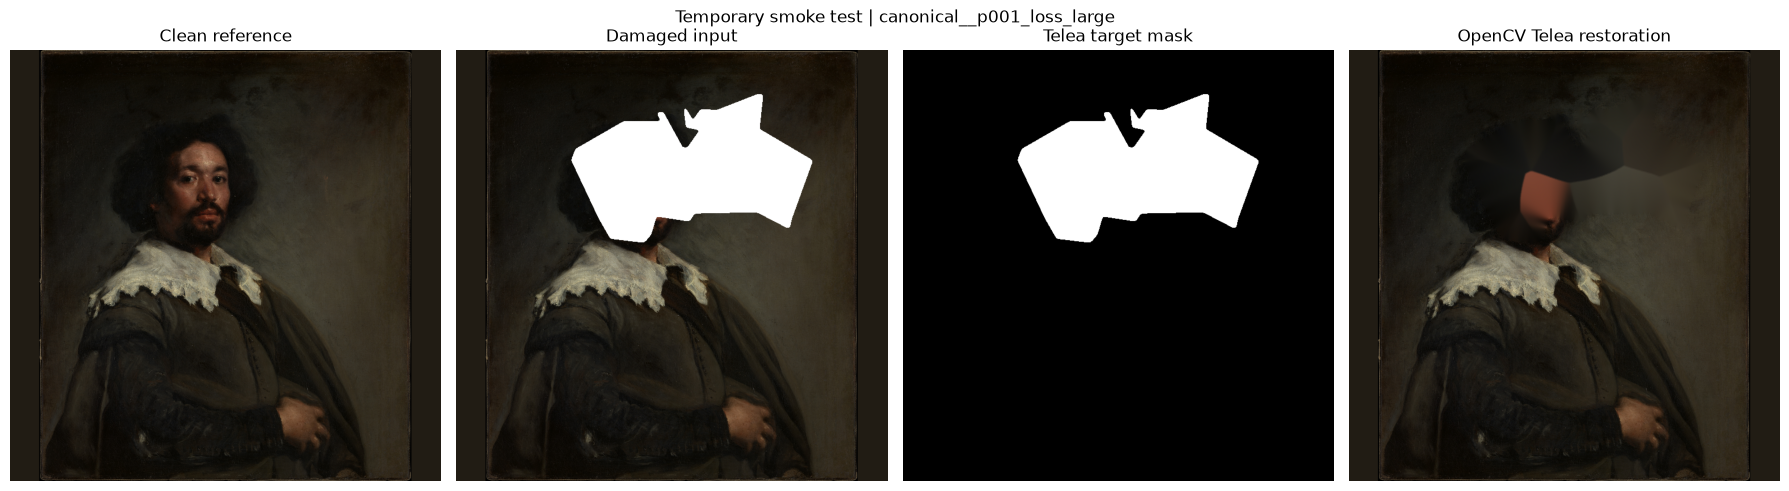

In [13]:
# Validate the temporary OpenCV Telea smoke-test output

opencv_smoke_file_validation_df = (
    validate_restored_images(
        restored_metadata=(
            opencv_smoke_metadata_df
        ),
        project_root=PROJECT_ROOT,
        target_size=TARGET_SIZE,
    )
)


opencv_smoke_behavior_validation_df = (
    validate_opencv_restoration_behavior(
        restored_metadata=(
            opencv_smoke_metadata_df
        ),
        project_root=PROJECT_ROOT,
        target_size=TARGET_SIZE,
    )
)


smoke_test_checks_df = pd.DataFrame(
    [
        {
            "check": (
                "generation_status_ok"
            ),
            "observed": str(
                opencv_smoke_metadata_df.loc[
                    0,
                    "status",
                ]
            ),
            "expected": "ok",
            "passed": (
                str(
                    opencv_smoke_metadata_df.loc[
                        0,
                        "status",
                    ]
                )
                == "ok"
            ),
        },
        {
            "check": (
                "file_validation_passed"
            ),
            "observed": bool(
                opencv_smoke_file_validation_df[
                    "validation_passed"
                ]
                .astype(bool)
                .all()
            ),
            "expected": True,
            "passed": bool(
                opencv_smoke_file_validation_df[
                    "validation_passed"
                ]
                .astype(bool)
                .all()
            ),
        },
        {
            "check": (
                "behavior_validation_passed"
            ),
            "observed": bool(
                opencv_smoke_behavior_validation_df[
                    "behavior_validation_passed"
                ]
                .astype(bool)
                .all()
            ),
            "expected": True,
            "passed": bool(
                opencv_smoke_behavior_validation_df[
                    "behavior_validation_passed"
                ]
                .astype(bool)
                .all()
            ),
        },
        {
            "check": (
                "runtime_positive"
            ),
            "observed": float(
                opencv_smoke_metadata_df.loc[
                    0,
                    "runtime_seconds",
                ]
            ),
            "expected": "> 0",
            "passed": (
                float(
                    opencv_smoke_metadata_df.loc[
                        0,
                        "runtime_seconds",
                    ]
                )
                > 0
            ),
        },
        {
            "check": (
                "opencv_version_recorded"
            ),
            "observed": str(
                opencv_smoke_metadata_df.loc[
                    0,
                    "opencv_version",
                ]
            ),
            "expected": cv2.__version__,
            "passed": (
                str(
                    opencv_smoke_metadata_df.loc[
                        0,
                        "opencv_version",
                    ]
                )
                == cv2.__version__
            ),
        },
        {
            "check": (
                "inpainting_radius_recorded"
            ),
            "observed": int(
                opencv_smoke_metadata_df.loc[
                    0,
                    "inpaint_radius",
                ]
            ),
            "expected": int(
                TELEA_RADIUS
            ),
            "passed": (
                int(
                    opencv_smoke_metadata_df.loc[
                        0,
                        "inpaint_radius",
                    ]
                )
                == int(
                    TELEA_RADIUS
                )
            ),
        },
    ]
)


print("Smoke-test file validation")
print("--------------------------")

display(
    opencv_smoke_file_validation_df
)


print("\nSmoke-test behavior validation")
print("------------------------------")

display(
    opencv_smoke_behavior_validation_df
)


print("\nSmoke-test checks")
print("-----------------")

display(
    smoke_test_checks_df
)


if not (
    smoke_test_checks_df[
        "passed"
    ]
    .astype(bool)
    .all()
):
    raise RuntimeError(
        "OpenCV Telea smoke-test validation "
        "failed."
    )


smoke_row = (
    opencv_smoke_metadata_df.iloc[
        0
    ]
)


with Image.open(
    resolve_project_path(
        smoke_row[
            "clean_path"
        ]
    )
) as image:
    smoke_clean_image = (
        image.convert(
            "RGB"
        ).copy()
    )


with Image.open(
    resolve_project_path(
        smoke_row[
            "damaged_path"
        ]
    )
) as image:
    smoke_damaged_image = (
        image.convert(
            "RGB"
        ).copy()
    )


with Image.open(
    resolve_project_path(
        smoke_row[
            "mask_path"
        ]
    )
) as image:
    smoke_mask_image = (
        image.convert(
            "L"
        ).copy()
    )


with Image.open(
    resolve_project_path(
        smoke_row[
            "restored_path"
        ]
    )
) as image:
    smoke_restored_image = (
        image.convert(
            "RGB"
        ).copy()
    )


smoke_figure, smoke_axes = (
    plt.subplots(
        1,
        4,
        figsize=(
            18,
            5,
        ),
    )
)


smoke_images = [
    smoke_clean_image,
    smoke_damaged_image,
    smoke_mask_image,
    smoke_restored_image,
]


smoke_titles = [
    "Clean reference",
    "Damaged input",
    "Telea target mask",
    "OpenCV Telea restoration",
]


for axis, image, title in zip(
    smoke_axes,
    smoke_images,
    smoke_titles,
):
    axis.imshow(
        image,
        cmap=(
            "gray"
            if title
            == "Telea target mask"
            else None
        ),
    )

    axis.set_title(
        title
    )

    axis.axis(
        "off"
    )


smoke_figure.suptitle(
    (
        f"Temporary smoke test | "
        f"{smoke_row['case_id']}"
    )
)


plt.tight_layout()
plt.show()
plt.close(
    smoke_figure
)

In [14]:
# Remove temporary smoke-test outputs before canonical generation

smoke_test_file_count_before_cleanup = len(
    list(
        temporary_smoke_test_dir.rglob(
            "*.png"
        )
    )
) if temporary_smoke_test_dir.exists() else 0


if temporary_smoke_test_dir.exists():
    shutil.rmtree(
        temporary_smoke_test_dir
    )


smoke_test_cleanup_df = pd.DataFrame(
    [
        {
            "artifact": (
                "temporary_smoke_test_directory"
            ),
            "path": project_relative_path(
                temporary_smoke_test_dir
            ),
            "png_count_before_cleanup": (
                smoke_test_file_count_before_cleanup
            ),
            "exists_after_cleanup": (
                temporary_smoke_test_dir.exists()
            ),
            "passed": (
                not temporary_smoke_test_dir.exists()
            ),
        }
    ]
)


display(
    smoke_test_cleanup_df
)


if not (
    smoke_test_cleanup_df[
        "passed"
    ]
    .astype(bool)
    .all()
):
    raise RuntimeError(
        "Temporary OpenCV smoke-test cleanup "
        "failed."
    )

,artifact,path,png_count_before_cleanup,exists_after_cleanup,passed
0,temporary_smoke_test_directory,outputs/08_opencv_telea/_temporary/smoke_test,1,False,True


In [15]:
# Generate the complete canonical OpenCV Telea restoration dataset

validate_restoration_input_manifest(
    restoration_input_manifest_df
)


opencv_restored_metadata_df = (
    create_opencv_restoration_dataset(
        restoration_input=(
            restoration_input_manifest_df
        ),
        restored_root_dir=(
            restored_root_dir
        ),
        project_root=PROJECT_ROOT,
        model_name=MODEL_NAME,
        radius=TELEA_RADIUS,
        overwrite=(
            OVERWRITE_RESTORATIONS
        ),
        compute_checksums=(
            COMPUTE_CHECKSUMS
        ),
    )
)


opencv_execution_summary_df = (
    summarize_opencv_restoration(
        opencv_restored_metadata_df
    )
)


failed_restoration_rows_df = (
    opencv_restored_metadata_df.loc[
        opencv_restored_metadata_df[
            "status"
        ]
        .astype(str)
        .ne(
            "ok"
        )
    ]
    .copy()
)


duplicate_generated_restoration_ids = (
    opencv_restored_metadata_df[
        "restoration_case_id"
    ]
    .astype(str)
    .duplicated(
        keep=False
    )
)


execution_checks_df = pd.DataFrame(
    [
        {
            "check": (
                "generated_metadata_row_count"
            ),
            "observed": len(
                opencv_restored_metadata_df
            ),
            "expected": (
                expected_total_restoration_count
            ),
            "passed": (
                len(
                    opencv_restored_metadata_df
                )
                == expected_total_restoration_count
            ),
        },
        {
            "check": (
                "successful_restoration_count"
            ),
            "observed": int(
                opencv_restored_metadata_df[
                    "status"
                ]
                .astype(str)
                .eq(
                    "ok"
                )
                .sum()
            ),
            "expected": (
                expected_total_restoration_count
            ),
            "passed": bool(
                opencv_restored_metadata_df[
                    "status"
                ]
                .astype(str)
                .eq(
                    "ok"
                )
                .all()
            ),
        },
        {
            "check": (
                "failed_restoration_count"
            ),
            "observed": len(
                failed_restoration_rows_df
            ),
            "expected": 0,
            "passed": (
                failed_restoration_rows_df.empty
            ),
        },
        {
            "check": (
                "restoration_ids_unique"
            ),
            "observed": int(
                duplicate_generated_restoration_ids.sum()
            ),
            "expected": 0,
            "passed": (
                not duplicate_generated_restoration_ids.any()
            ),
        },
        {
            "check": (
                "runtime_values_nonnegative"
            ),
            "observed": int(
                opencv_restored_metadata_df[
                    "runtime_seconds"
                ]
                .astype(float)
                .ge(
                    0
                )
                .sum()
            ),
            "expected": len(
                opencv_restored_metadata_df
            ),
            "passed": bool(
                opencv_restored_metadata_df[
                    "runtime_seconds"
                ]
                .astype(float)
                .ge(
                    0
                )
                .all()
            ),
        },
        {
            "check": (
                "opencv_version_consistent"
            ),
            "observed": sorted(
                opencv_restored_metadata_df[
                    "opencv_version"
                ]
                .astype(str)
                .unique()
                .tolist()
            ),
            "expected": [
                cv2.__version__
            ],
            "passed": (
                set(
                    opencv_restored_metadata_df[
                        "opencv_version"
                    ]
                    .astype(str)
                )
                == {
                    cv2.__version__
                }
            ),
        },
        {
            "check": (
                "inpainting_radius_consistent"
            ),
            "observed": sorted(
                opencv_restored_metadata_df[
                    "inpaint_radius"
                ]
                .astype(int)
                .unique()
                .tolist()
            ),
            "expected": [
                int(
                    TELEA_RADIUS
                )
            ],
            "passed": (
                set(
                    opencv_restored_metadata_df[
                        "inpaint_radius"
                    ]
                    .astype(int)
                )
                == {
                    int(
                        TELEA_RADIUS
                    )
                }
            ),
        },
        {
            "check": (
                "algorithm_consistent"
            ),
            "observed": sorted(
                opencv_restored_metadata_df[
                    "algorithm"
                ]
                .astype(str)
                .unique()
                .tolist()
            ),
            "expected": [
                "cv2.INPAINT_TELEA"
            ],
            "passed": (
                set(
                    opencv_restored_metadata_df[
                        "algorithm"
                    ]
                    .astype(str)
                )
                == {
                    "cv2.INPAINT_TELEA"
                }
            ),
        },
    ]
)


print("OpenCV Telea execution summary")
print("------------------------------")

display(
    opencv_execution_summary_df
)


print("\nExecution checks")
print("----------------")

display(
    execution_checks_df
)


if not failed_restoration_rows_df.empty:
    print(
        "\nFailed restoration rows"
    )

    display(
        failed_restoration_rows_df[
            [
                "dataset_name",
                "case_id",
                "painting_id",
                "status",
                "issue",
            ]
        ]
    )


if not (
    execution_checks_df[
        "passed"
    ]
    .astype(bool)
    .all()
):
    raise RuntimeError(
        "Full OpenCV Telea restoration "
        "execution failed validation."
    )


print(
    "\nGenerated OpenCV Telea restorations:",
    len(
        opencv_restored_metadata_df
    ),
)

OpenCV Telea execution summary
------------------------------


,dataset_name,input_cases,successful_cases,failed_cases,total_runtime_seconds,mean_runtime_seconds,median_runtime_seconds,max_runtime_seconds
0,canonical,250,250,0,118.215902,0.472864,0.465435,0.830250
1,damage_size,35,35,0,18.096896,0.517054,0.489979,0.822646
2,mask_robustness,75,75,0,35.254925,0.470066,0.441835,0.685556
3,synthetic_degradation,50,50,0,24.470881,0.489418,0.445519,1.181796



Execution checks
----------------


,check,observed,expected,passed
0,generated_metadata_row_count,410,410,True
1,successful_restoration_count,410,410,True
2,failed_restoration_count,0,0,True
3,restoration_ids_unique,0,0,True
4,runtime_values_nonnegative,410,410,True
5,opencv_version_consistent,[4.11.0],[4.11.0],True
6,inpainting_radius_consistent,[3],[3],True
7,algorithm_consistent,[cv2.INPAINT_TELEA],[cv2.INPAINT_TELEA],True



Generated OpenCV Telea restorations: 410


In [16]:
# Validate every generated OpenCV Telea restoration file

opencv_file_validation_df = (
    validate_restored_images(
        restored_metadata=(
            opencv_restored_metadata_df
        ),
        project_root=PROJECT_ROOT,
        target_size=TARGET_SIZE,
    )
)


failed_file_validation_df = (
    opencv_file_validation_df.loc[
        ~opencv_file_validation_df[
            "validation_passed"
        ]
        .astype(bool)
    ]
    .copy()
)


file_validation_summary_df = (
    opencv_file_validation_df
    .groupby(
        "dataset_name",
        dropna=False,
        sort=False,
    )
    .agg(
        validated_cases=(
            "restoration_case_id",
            "count",
        ),
        passed_cases=(
            "validation_passed",
            lambda values: int(
                values.astype(bool).sum()
            ),
        ),
        failed_cases=(
            "validation_passed",
            lambda values: int(
                (
                    ~values.astype(bool)
                ).sum()
            ),
        ),
        existing_files=(
            "file_exists",
            lambda values: int(
                values.astype(bool).sum()
            ),
        ),
        readable_files=(
            "readable",
            lambda values: int(
                values.astype(bool).sum()
            ),
        ),
    )
    .reset_index()
)


file_validation_checks_df = pd.DataFrame(
    [
        {
            "check": "validation_row_count",
            "observed": len(
                opencv_file_validation_df
            ),
            "expected": len(
                opencv_restored_metadata_df
            ),
            "passed": (
                len(
                    opencv_file_validation_df
                )
                == len(
                    opencv_restored_metadata_df
                )
            ),
        },
        {
            "check": "all_restored_files_exist",
            "observed": int(
                opencv_file_validation_df[
                    "file_exists"
                ]
                .astype(bool)
                .sum()
            ),
            "expected": len(
                opencv_file_validation_df
            ),
            "passed": bool(
                opencv_file_validation_df[
                    "file_exists"
                ]
                .astype(bool)
                .all()
            ),
        },
        {
            "check": "all_restored_files_readable",
            "observed": int(
                opencv_file_validation_df[
                    "readable"
                ]
                .astype(bool)
                .sum()
            ),
            "expected": len(
                opencv_file_validation_df
            ),
            "passed": bool(
                opencv_file_validation_df[
                    "readable"
                ]
                .astype(bool)
                .all()
            ),
        },
        {
            "check": "all_restored_sizes_valid",
            "observed": int(
                (
                    opencv_file_validation_df[
                        "width"
                    ]
                    .eq(TARGET_SIZE)
                    &
                    opencv_file_validation_df[
                        "height"
                    ]
                    .eq(TARGET_SIZE)
                ).sum()
            ),
            "expected": len(
                opencv_file_validation_df
            ),
            "passed": bool(
                (
                    opencv_file_validation_df[
                        "width"
                    ]
                    .eq(TARGET_SIZE)
                    &
                    opencv_file_validation_df[
                        "height"
                    ]
                    .eq(TARGET_SIZE)
                ).all()
            ),
        },
        {
            "check": "all_restored_modes_rgb",
            "observed": int(
                opencv_file_validation_df[
                    "mode"
                ]
                .astype(str)
                .eq("RGB")
                .sum()
            ),
            "expected": len(
                opencv_file_validation_df
            ),
            "passed": bool(
                opencv_file_validation_df[
                    "mode"
                ]
                .astype(str)
                .eq("RGB")
                .all()
            ),
        },
        {
            "check": "all_recorded_checksums_match",
            "observed": int(
                opencv_file_validation_df[
                    "checksum_matches"
                ]
                .fillna(False)
                .astype(bool)
                .sum()
            ),
            "expected": len(
                opencv_file_validation_df
            ),
            "passed": bool(
                opencv_file_validation_df[
                    "checksum_matches"
                ]
                .fillna(False)
                .astype(bool)
                .all()
            ),
        },
        {
            "check": "all_file_validations_passed",
            "observed": int(
                opencv_file_validation_df[
                    "validation_passed"
                ]
                .astype(bool)
                .sum()
            ),
            "expected": len(
                opencv_file_validation_df
            ),
            "passed": bool(
                opencv_file_validation_df[
                    "validation_passed"
                ]
                .astype(bool)
                .all()
            ),
        },
    ]
)


print("Restored-file validation summary")
print("--------------------------------")

display(
    file_validation_summary_df
)


print("\nRestored-file validation checks")
print("--------------------------------")

display(
    file_validation_checks_df
)


if not failed_file_validation_df.empty:
    print("\nFailed restored-file validations")

    display(
        failed_file_validation_df[
            [
                "dataset_name",
                "case_id",
                "restoration_case_id",
                "restored_path",
                "issue",
            ]
        ]
    )


if not (
    file_validation_checks_df[
        "passed"
    ]
    .astype(bool)
    .all()
):
    raise RuntimeError(
        "OpenCV restored-file validation failed."
    )

Restored-file validation summary
--------------------------------


,dataset_name,validated_cases,passed_cases,failed_cases,existing_files,readable_files
0,canonical,250,250,0,250,250
1,damage_size,35,35,0,35,35
2,mask_robustness,75,75,0,75,75
3,synthetic_degradation,50,50,0,50,50



Restored-file validation checks
--------------------------------


,check,observed,expected,passed
0,validation_row_count,410,410,True
1,all_restored_files_exist,410,410,True
2,all_restored_files_readable,410,410,True
3,all_restored_sizes_valid,410,410,True
4,all_restored_modes_rgb,410,410,True
5,all_recorded_checksums_match,410,410,True
6,all_file_validations_passed,410,410,True


In [17]:
# Validate basic OpenCV Telea inpainting behavior

opencv_behavior_validation_df = (
    validate_opencv_restoration_behavior(
        restored_metadata=(
            opencv_restored_metadata_df
        ),
        project_root=PROJECT_ROOT,
        target_size=TARGET_SIZE,
    )
)


failed_behavior_validation_df = (
    opencv_behavior_validation_df.loc[
        ~opencv_behavior_validation_df[
            "behavior_validation_passed"
        ]
        .astype(bool)
    ]
    .copy()
)


behavior_validation_summary_df = (
    opencv_behavior_validation_df
    .groupby(
        "dataset_name",
        dropna=False,
        sort=False,
    )
    .agg(
        validated_cases=(
            "restoration_case_id",
            "count",
        ),
        passed_cases=(
            "behavior_validation_passed",
            lambda values: int(
                values.astype(bool).sum()
            ),
        ),
        failed_cases=(
            "behavior_validation_passed",
            lambda values: int(
                (
                    ~values.astype(bool)
                ).sum()
            ),
        ),
        total_mask_area_pixels=(
            "mask_area_pixels",
            "sum",
        ),
        total_changed_pixels=(
            "changed_pixels_vs_damaged",
            "sum",
        ),
        total_changed_inside_mask=(
            "changed_pixels_inside_mask",
            "sum",
        ),
        total_changed_outside_mask=(
            "changed_pixels_outside_mask",
            "sum",
        ),
        mean_changed_inside_mask=(
            "changed_pixels_inside_mask",
            "mean",
        ),
    )
    .reset_index()
)


empty_mask_behavior_df = (
    opencv_behavior_validation_df.loc[
        opencv_behavior_validation_df[
            "mask_area_pixels"
        ]
        .fillna(-1)
        .astype(float)
        .eq(0)
    ]
    .copy()
)


nonempty_mask_behavior_df = (
    opencv_behavior_validation_df.loc[
        opencv_behavior_validation_df[
            "mask_area_pixels"
        ]
        .fillna(-1)
        .astype(float)
        .gt(0)
    ]
    .copy()
)


behavior_validation_checks_df = pd.DataFrame(
    [
        {
            "check": "behavior_validation_row_count",
            "observed": len(
                opencv_behavior_validation_df
            ),
            "expected": len(
                opencv_restored_metadata_df
            ),
            "passed": (
                len(
                    opencv_behavior_validation_df
                )
                == len(
                    opencv_restored_metadata_df
                )
            ),
        },
        {
            "check": "outside_mask_preserved",
            "observed": int(
                opencv_behavior_validation_df[
                    "outside_mask_preserved"
                ]
                .fillna(False)
                .astype(bool)
                .sum()
            ),
            "expected": len(
                opencv_behavior_validation_df
            ),
            "passed": bool(
                opencv_behavior_validation_df[
                    "outside_mask_preserved"
                ]
                .fillna(False)
                .astype(bool)
                .all()
            ),
        },
        {
            "check": "empty_masks_leave_images_unchanged",
            "observed": int(
                empty_mask_behavior_df[
                    "empty_mask_unchanged"
                ]
                .fillna(False)
                .astype(bool)
                .sum()
            ),
            "expected": len(
                empty_mask_behavior_df
            ),
            "passed": (
                empty_mask_behavior_df.empty
                or bool(
                    empty_mask_behavior_df[
                        "empty_mask_unchanged"
                    ]
                    .fillna(False)
                    .astype(bool)
                    .all()
                )
            ),
        },
        {
            "check": "nonempty_masks_change_target_region",
            "observed": int(
                nonempty_mask_behavior_df[
                    "nonempty_mask_changed"
                ]
                .fillna(False)
                .astype(bool)
                .sum()
            ),
            "expected": len(
                nonempty_mask_behavior_df
            ),
            "passed": (
                nonempty_mask_behavior_df.empty
                or bool(
                    nonempty_mask_behavior_df[
                        "nonempty_mask_changed"
                    ]
                    .fillna(False)
                    .astype(bool)
                    .all()
                )
            ),
        },
        {
            "check": "all_behavior_validations_passed",
            "observed": int(
                opencv_behavior_validation_df[
                    "behavior_validation_passed"
                ]
                .astype(bool)
                .sum()
            ),
            "expected": len(
                opencv_behavior_validation_df
            ),
            "passed": bool(
                opencv_behavior_validation_df[
                    "behavior_validation_passed"
                ]
                .astype(bool)
                .all()
            ),
        },
    ]
)


print("Behavior-validation summary")
print("---------------------------")

display(
    behavior_validation_summary_df
)


print("\nBehavior-validation checks")
print("--------------------------")

display(
    behavior_validation_checks_df
)


if not failed_behavior_validation_df.empty:
    print("\nFailed behavior validations")

    display(
        failed_behavior_validation_df[
            [
                "dataset_name",
                "case_id",
                "restoration_case_id",
                "mask_area_pixels",
                "changed_pixels_inside_mask",
                "changed_pixels_outside_mask",
                "issue",
            ]
        ]
    )


if not (
    behavior_validation_checks_df[
        "passed"
    ]
    .astype(bool)
    .all()
):
    raise RuntimeError(
        "OpenCV restoration behavior validation failed."
    )

Behavior-validation summary
---------------------------


E:\HFCache\tmp\ipykernel_5388\49200363.py:149: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)
E:\HFCache\tmp\ipykernel_5388\49200363.py:162: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)
E:\HFCache\tmp\ipykernel_5388\49200363.py:174: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)
E:\HFCache\tmp\i

,dataset_name,validated_cases,passed_cases,failed_cases,total_mask_area_pixels,total_changed_pixels,total_changed_inside_mask,total_changed_outside_mask,mean_changed_inside_mask
0,canonical,250,250,0,6372340,6372340,6372340,0,25489.360000
1,damage_size,35,35,0,1434579,1434579,1434579,0,40987.971429
2,mask_robustness,75,75,0,2093429,2093429,2093429,0,27912.386667
3,synthetic_degradation,50,50,0,1864448,1861984,1861984,0,37239.680000



Behavior-validation checks
--------------------------


,check,observed,expected,passed
0,behavior_validation_row_count,410,410,True
1,outside_mask_preserved,410,410,True
2,empty_masks_leave_images_unchanged,55,55,True
3,nonempty_masks_change_target_region,355,355,True
4,all_behavior_validations_passed,410,410,True


In [18]:
# Compare expected metadata outputs with observed restored PNG files

opencv_inventory_audit_df = (
    audit_opencv_restoration_inventory(
        restored_metadata=(
            opencv_restored_metadata_df
        ),
        restored_root_dir=(
            restored_root_dir
        ),
        project_root=PROJECT_ROOT,
    )
)


missing_inventory_rows_df = (
    opencv_inventory_audit_df.loc[
        opencv_inventory_audit_df[
            "record_type"
        ]
        .astype(str)
        .eq("expected")
        &
        ~opencv_inventory_audit_df[
            "inventory_passed"
        ]
        .astype(bool)
    ]
    .copy()
)


unexpected_inventory_rows_df = (
    opencv_inventory_audit_df.loc[
        opencv_inventory_audit_df[
            "unexpected"
        ]
        .astype(bool)
    ]
    .copy()
)


inventory_summary_df = pd.DataFrame(
    [
        {
            "metric": "expected_metadata_records",
            "value": len(
                opencv_restored_metadata_df
            ),
        },
        {
            "metric": "observed_png_files",
            "value": len(
                list(
                    restored_root_dir.rglob(
                        "*.png"
                    )
                )
            ),
        },
        {
            "metric": "missing_expected_files",
            "value": len(
                missing_inventory_rows_df
            ),
        },
        {
            "metric": "unexpected_files",
            "value": len(
                unexpected_inventory_rows_df
            ),
        },
    ]
)


inventory_checks_df = pd.DataFrame(
    [
        {
            "check": "expected_inventory_row_count",
            "observed": int(
                opencv_inventory_audit_df[
                    "record_type"
                ]
                .astype(str)
                .eq("expected")
                .sum()
            ),
            "expected": len(
                opencv_restored_metadata_df
            ),
            "passed": (
                int(
                    opencv_inventory_audit_df[
                        "record_type"
                    ]
                    .astype(str)
                    .eq("expected")
                    .sum()
                )
                == len(
                    opencv_restored_metadata_df
                )
            ),
        },
        {
            "check": "no_missing_restored_files",
            "observed": len(
                missing_inventory_rows_df
            ),
            "expected": 0,
            "passed": (
                missing_inventory_rows_df.empty
            ),
        },
        {
            "check": "no_unexpected_restored_files",
            "observed": len(
                unexpected_inventory_rows_df
            ),
            "expected": 0,
            "passed": (
                unexpected_inventory_rows_df.empty
            ),
        },
        {
            "check": "all_inventory_records_passed",
            "observed": int(
                opencv_inventory_audit_df[
                    "inventory_passed"
                ]
                .astype(bool)
                .sum()
            ),
            "expected": len(
                opencv_inventory_audit_df
            ),
            "passed": bool(
                opencv_inventory_audit_df[
                    "inventory_passed"
                ]
                .astype(bool)
                .all()
            ),
        },
    ]
)


print("Restoration inventory summary")
print("-----------------------------")

display(
    inventory_summary_df
)


print("\nInventory checks")
print("----------------")

display(
    inventory_checks_df
)


if not missing_inventory_rows_df.empty:
    display(
        missing_inventory_rows_df
    )


if not unexpected_inventory_rows_df.empty:
    display(
        unexpected_inventory_rows_df
    )


if not (
    inventory_checks_df[
        "passed"
    ]
    .astype(bool)
    .all()
):
    raise RuntimeError(
        "OpenCV restoration inventory audit failed."
    )

Restoration inventory summary
-----------------------------


,metric,value
0,expected_metadata_records,410
1,observed_png_files,410
2,missing_expected_files,0
3,unexpected_files,0



Inventory checks
----------------


,check,observed,expected,passed
0,expected_inventory_row_count,410,410,True
1,no_missing_restored_files,0,0,True
2,no_unexpected_restored_files,0,0,True
3,all_inventory_records_passed,410,410,True


In [19]:
# Verify deterministic output for one representative case per dataset

determinism_input_df = (
    restoration_input_manifest_df
    .sort_values(
        [
            "dataset_name",
            "painting_id",
            "case_id",
        ],
        kind="stable",
    )
    .groupby(
        "dataset_name",
        sort=False,
        as_index=False,
    )
    .head(1)
    .reset_index(
        drop=True
    )
)


validate_restoration_input_manifest(
    determinism_input_df
)


if temporary_determinism_dir.exists():
    shutil.rmtree(
        temporary_determinism_dir
    )


temporary_determinism_dir.mkdir(
    parents=True,
    exist_ok=True,
)


determinism_regenerated_metadata_df = (
    create_opencv_restoration_dataset(
        restoration_input=(
            determinism_input_df
        ),
        restored_root_dir=(
            temporary_determinism_dir
        ),
        project_root=PROJECT_ROOT,
        model_name=MODEL_NAME,
        radius=TELEA_RADIUS,
        overwrite=True,
        compute_checksums=True,
    )
)


canonical_checksum_lookup_df = (
    opencv_restored_metadata_df[
        [
            "restoration_case_id",
            "dataset_name",
            "case_id",
            "restored_sha256",
        ]
    ]
    .rename(
        columns={
            "restored_sha256": (
                "canonical_restored_sha256"
            ),
        }
    )
)


determinism_audit_df = (
    determinism_regenerated_metadata_df[
        [
            "restoration_case_id",
            "dataset_name",
            "case_id",
            "status",
            "restored_path",
            "restored_sha256",
            "runtime_seconds",
        ]
    ]
    .rename(
        columns={
            "status": "regeneration_status",
            "restored_path": (
                "regenerated_restored_path"
            ),
            "restored_sha256": (
                "regenerated_restored_sha256"
            ),
            "runtime_seconds": (
                "regeneration_runtime_seconds"
            ),
        }
    )
    .merge(
        canonical_checksum_lookup_df,
        on=[
            "restoration_case_id",
            "dataset_name",
            "case_id",
        ],
        how="left",
        validate="one_to_one",
    )
)


determinism_audit_df[
    "checksum_matches"
] = (
    determinism_audit_df[
        "regenerated_restored_sha256"
    ]
    .astype(str)
    .eq(
        determinism_audit_df[
            "canonical_restored_sha256"
        ]
        .astype(str)
    )
)


determinism_audit_df[
    "determinism_passed"
] = (
    determinism_audit_df[
        "regeneration_status"
    ]
    .astype(str)
    .eq("ok")
    &
    determinism_audit_df[
        "checksum_matches"
    ]
    .astype(bool)
)


determinism_checks_df = pd.DataFrame(
    [
        {
            "check": (
                "representative_case_per_dataset"
            ),
            "observed": len(
                determinism_audit_df
            ),
            "expected": (
                restoration_input_manifest_df[
                    "dataset_name"
                ]
                .astype(str)
                .nunique()
            ),
            "passed": (
                len(
                    determinism_audit_df
                )
                == restoration_input_manifest_df[
                    "dataset_name"
                ]
                .astype(str)
                .nunique()
            ),
        },
        {
            "check": (
                "all_regenerations_succeeded"
            ),
            "observed": int(
                determinism_audit_df[
                    "regeneration_status"
                ]
                .astype(str)
                .eq("ok")
                .sum()
            ),
            "expected": len(
                determinism_audit_df
            ),
            "passed": bool(
                determinism_audit_df[
                    "regeneration_status"
                ]
                .astype(str)
                .eq("ok")
                .all()
            ),
        },
        {
            "check": (
                "all_regenerated_checksums_match"
            ),
            "observed": int(
                determinism_audit_df[
                    "checksum_matches"
                ]
                .astype(bool)
                .sum()
            ),
            "expected": len(
                determinism_audit_df
            ),
            "passed": bool(
                determinism_audit_df[
                    "checksum_matches"
                ]
                .astype(bool)
                .all()
            ),
        },
    ]
)


print("Deterministic regeneration audit")
print("--------------------------------")

display(
    determinism_audit_df
)


display(
    determinism_checks_df
)


if not (
    determinism_checks_df[
        "passed"
    ]
    .astype(bool)
    .all()
):
    raise RuntimeError(
        "OpenCV deterministic regeneration audit failed."
    )


determinism_png_count_before_cleanup = len(
    list(
        temporary_determinism_dir.rglob(
            "*.png"
        )
    )
)


shutil.rmtree(
    temporary_determinism_dir
)


determinism_cleanup_df = pd.DataFrame(
    [
        {
            "artifact": (
                "temporary_determinism_directory"
            ),
            "png_count_before_cleanup": (
                determinism_png_count_before_cleanup
            ),
            "exists_after_cleanup": (
                temporary_determinism_dir.exists()
            ),
            "passed": (
                not temporary_determinism_dir.exists()
            ),
        }
    ]
)


display(
    determinism_cleanup_df
)


if not (
    determinism_cleanup_df[
        "passed"
    ]
    .astype(bool)
    .all()
):
    raise RuntimeError(
        "Determinism temporary-output cleanup failed."
    )

Deterministic regeneration audit
--------------------------------


,restoration_case_id,dataset_name,case_id,regeneration_status,regenerated_restored_path,regenerated_restored_sha256,regeneration_runtime_seconds,canonical_restored_sha256,checksum_matches,determinism_passed
0,opencv_telea__canonical__canonical__p001_loss_...,canonical,canonical__p001_loss_large,ok,outputs\08_opencv_telea\_temporary\determinism...,639e64fb1d4f8a415159507ccfb9c6b0603c80c1caf984...,0.643567,639e64fb1d4f8a415159507ccfb9c6b0603c80c1caf984...,True,True
1,opencv_telea__damage_size__damage_size__p001__...,damage_size,damage_size__p001__loss_large__size_02pct,ok,outputs\08_opencv_telea\_temporary\determinism...,7ccbd16f508ceba2cfbdb9f3de5b15bdce0a858db275da...,0.535507,7ccbd16f508ceba2cfbdb9f3de5b15bdce0a858db275da...,True,True
2,opencv_telea__mask_robustness__mask_robustness...,mask_robustness,mask_robustness__p001__loss_large__variant_01,ok,outputs\08_opencv_telea\_temporary\determinism...,35c31a565fa2cc487f0a16e63385c0c8a48949ddde740e...,0.632036,35c31a565fa2cc487f0a16e63385c0c8a48949ddde740e...,True,True
3,opencv_telea__synthetic_degradation__synthetic...,synthetic_degradation,synthetic_degradation__p001__dirt_dust__mild,ok,outputs\08_opencv_telea\_temporary\determinism...,9d1331c2f80c0a3afeea233b92bb8a2beb595ba9ea79fe...,0.523429,9d1331c2f80c0a3afeea233b92bb8a2beb595ba9ea79fe...,True,True


,check,observed,expected,passed
0,representative_case_per_dataset,4,4,True
1,all_regenerations_succeeded,4,4,True
2,all_regenerated_checksums_match,4,4,True


,artifact,png_count_before_cleanup,exists_after_cleanup,passed
0,temporary_determinism_directory,4,False,True


In [20]:
# Write the canonical OpenCV Telea restoration metadata

metadata_columns_first = [
    "restoration_case_id",
    "model_name",
    "algorithm",
    "inpaint_radius",
    "opencv_version",
    "restoration_generator_name",
    "restoration_generator_version",
    "dataset_name",
    "source_case_id",
    "source_case_id_original",
    "case_id",
    "painting_id",
    "telea_applicability",
    "source_mask_semantics",
    "telea_mask_threshold",
    "clean_path",
    "damaged_path",
    "mask_path",
    "restored_filename",
    "restored_path",
    "restored_sha256",
    "runtime_seconds",
    "started_at_utc",
    "completed_at_utc",
    "output_written",
    "status",
    "issue",
    "source_metadata_path",
]


available_metadata_columns_first = [
    column_name
    for column_name in metadata_columns_first
    if column_name
    in opencv_restored_metadata_df.columns
]


remaining_metadata_columns = [
    column_name
    for column_name
    in opencv_restored_metadata_df.columns
    if column_name
    not in available_metadata_columns_first
]


opencv_restored_metadata_df = (
    opencv_restored_metadata_df[
        available_metadata_columns_first
        + remaining_metadata_columns
    ]
    .sort_values(
        [
            "dataset_name",
            "painting_id",
            "case_id",
        ],
        kind="stable",
    )
    .reset_index(
        drop=True
    )
)


opencv_metadata_path.parent.mkdir(
    parents=True,
    exist_ok=True,
)


opencv_restored_metadata_df.to_csv(
    opencv_metadata_path,
    index=False,
)


opencv_restored_metadata_reloaded_df = (
    pd.read_csv(
        opencv_metadata_path
    )
)


metadata_save_checks_df = pd.DataFrame(
    [
        {
            "check": "metadata_file_exists",
            "observed": (
                opencv_metadata_path.is_file()
            ),
            "expected": True,
            "passed": (
                opencv_metadata_path.is_file()
            ),
        },
        {
            "check": "metadata_file_nonempty",
            "observed": (
                opencv_metadata_path.stat().st_size
                if opencv_metadata_path.exists()
                else 0
            ),
            "expected": "> 0",
            "passed": (
                opencv_metadata_path.exists()
                and
                opencv_metadata_path.stat().st_size
                > 0
            ),
        },
        {
            "check": "reloaded_metadata_row_count",
            "observed": len(
                opencv_restored_metadata_reloaded_df
            ),
            "expected": len(
                opencv_restored_metadata_df
            ),
            "passed": (
                len(
                    opencv_restored_metadata_reloaded_df
                )
                == len(
                    opencv_restored_metadata_df
                )
            ),
        },
        {
            "check": "reloaded_case_ids_unique",
            "observed": int(
                opencv_restored_metadata_reloaded_df[
                    "restoration_case_id"
                ]
                .astype(str)
                .duplicated()
                .sum()
            ),
            "expected": 0,
            "passed": (
                not opencv_restored_metadata_reloaded_df[
                    "restoration_case_id"
                ]
                .astype(str)
                .duplicated()
                .any()
            ),
        },
        {
            "check": "reloaded_statuses_ok",
            "observed": int(
                opencv_restored_metadata_reloaded_df[
                    "status"
                ]
                .astype(str)
                .eq("ok")
                .sum()
            ),
            "expected": len(
                opencv_restored_metadata_reloaded_df
            ),
            "passed": bool(
                opencv_restored_metadata_reloaded_df[
                    "status"
                ]
                .astype(str)
                .eq("ok")
                .all()
            ),
        },
    ]
)


print(
    "Canonical metadata:",
    project_relative_path(
        opencv_metadata_path
    ),
)


display(
    metadata_save_checks_df
)


if not (
    metadata_save_checks_df[
        "passed"
    ]
    .astype(bool)
    .all()
):
    raise RuntimeError(
        "Canonical OpenCV metadata save/reload validation failed."
    )

Canonical metadata: data/processed/metadata/metadata_restored_opencv_telea.csv


,check,observed,expected,passed
0,metadata_file_exists,True,True,True
1,metadata_file_nonempty,719288,> 0,True
2,reloaded_metadata_row_count,410,410,True
3,reloaded_case_ids_unique,0,0,True
4,reloaded_statuses_ok,410,410,True


In [21]:
# Consolidate Notebook 08 checks into the canonical audit CSV

def standardize_check_table(
    dataframe: pd.DataFrame,
    audit_section: str,
) -> pd.DataFrame:
    """Normalize a notebook check table for the canonical audit."""
    standardized_df = dataframe.copy()

    standardized_df.insert(
        0,
        "audit_section",
        audit_section,
    )

    standardized_df["check"] = (
        standardized_df[
            "check"
        ]
        .astype(str)
    )

    standardized_df["observed"] = (
        standardized_df[
            "observed"
        ]
        .astype(object)
        .where(
            pd.notna(
                standardized_df[
                    "observed"
                ]
            ),
            "",
        )
        .astype(str)
    )

    standardized_df["expected"] = (
        standardized_df[
            "expected"
        ]
        .astype(object)
        .where(
            pd.notna(
                standardized_df[
                    "expected"
                ]
            ),
            "",
        )
        .astype(str)
    )

    standardized_df["passed"] = (
        standardized_df[
            "passed"
        ]
        .astype(bool)
    )

    return standardized_df[
        [
            "audit_section",
            "check",
            "observed",
            "expected",
            "passed",
        ]
    ]


opencv_audit_df = pd.concat(
    [
        standardize_check_table(
            restoration_input_checks_df,
            "input_manifest",
        ),
        standardize_check_table(
            expected_restoration_checks_df,
            "expected_manifest",
        ),
        standardize_check_table(
            cleanup_checks_df,
            "pre_generation_cleanup",
        ),
        standardize_check_table(
            smoke_test_checks_df,
            "smoke_test",
        ),
        standardize_check_table(
            smoke_test_cleanup_df.rename(
                columns={
                    "artifact": "check",
                    "exists_after_cleanup": (
                        "observed"
                    ),
                }
            ).assign(
                expected=False
            )[
                [
                    "check",
                    "observed",
                    "expected",
                    "passed",
                ]
            ],
            "smoke_test_cleanup",
        ),
        standardize_check_table(
            execution_checks_df,
            "restoration_execution",
        ),
        standardize_check_table(
            file_validation_checks_df,
            "file_validation",
        ),
        standardize_check_table(
            behavior_validation_checks_df,
            "behavior_validation",
        ),
        standardize_check_table(
            inventory_checks_df,
            "inventory",
        ),
        standardize_check_table(
            determinism_checks_df,
            "determinism",
        ),
        standardize_check_table(
            metadata_save_checks_df,
            "metadata_save",
        ),
    ],
    ignore_index=True,
)


opencv_audit_df.insert(
    0,
    "notebook",
    "08_opencv_telea_restoration",
)


opencv_audit_df.insert(
    1,
    "model_name",
    MODEL_NAME,
)


opencv_audit_df.insert(
    2,
    "generated_at_utc",
    datetime.now(
        timezone.utc
    ).isoformat(),
)


opencv_audit_path.parent.mkdir(
    parents=True,
    exist_ok=True,
)


opencv_audit_df.to_csv(
    opencv_audit_path,
    index=False,
)


opencv_audit_reloaded_df = pd.read_csv(
    opencv_audit_path
)


audit_save_checks_df = pd.DataFrame(
    [
        {
            "check": "audit_file_exists",
            "observed": (
                opencv_audit_path.is_file()
            ),
            "expected": True,
            "passed": (
                opencv_audit_path.is_file()
            ),
        },
        {
            "check": "audit_file_nonempty",
            "observed": (
                opencv_audit_path.stat().st_size
                if opencv_audit_path.exists()
                else 0
            ),
            "expected": "> 0",
            "passed": (
                opencv_audit_path.exists()
                and
                opencv_audit_path.stat().st_size
                > 0
            ),
        },
        {
            "check": "audit_row_count_preserved",
            "observed": len(
                opencv_audit_reloaded_df
            ),
            "expected": len(
                opencv_audit_df
            ),
            "passed": (
                len(
                    opencv_audit_reloaded_df
                )
                == len(
                    opencv_audit_df
                )
            ),
        },
        {
            "check": "all_audit_checks_passed",
            "observed": int(
                opencv_audit_df[
                    "passed"
                ]
                .astype(bool)
                .sum()
            ),
            "expected": len(
                opencv_audit_df
            ),
            "passed": bool(
                opencv_audit_df[
                    "passed"
                ]
                .astype(bool)
                .all()
            ),
        },
    ]
)


print(
    "Canonical audit:",
    project_relative_path(
        opencv_audit_path
    ),
)


display(
    opencv_audit_df
)


display(
    audit_save_checks_df
)


if not (
    audit_save_checks_df[
        "passed"
    ]
    .astype(bool)
    .all()
):
    raise RuntimeError(
        "Canonical OpenCV audit save validation failed."
    )

Canonical audit: outputs/08_opencv_telea/opencv_telea_audit.csv


,notebook,model_name,generated_at_utc,audit_section,check,observed,expected,passed
0,08_opencv_telea_restoration,opencv_telea,2026-07-25T20:26:51.102447+00:00,input_manifest,manifest_nonempty,410,> 0,True
1,08_opencv_telea_restoration,opencv_telea,2026-07-25T20:26:51.102447+00:00,input_manifest,global_case_ids_unique,0,0,True
2,08_opencv_telea_restoration,opencv_telea,2026-07-25T20:26:51.102447+00:00,input_manifest,required_values_nonnull,False,False,True
3,08_opencv_telea_restoration,opencv_telea,2026-07-25T20:26:51.102447+00:00,input_manifest,required_values_nonempty,False,False,True
4,08_opencv_telea_restoration,opencv_telea,2026-07-25T20:26:51.102447+00:00,input_manifest,all_input_paths_exist,410,410,True
5,08_opencv_telea_restoration,opencv_telea,2026-07-25T20:26:51.102447+00:00,input_manifest,required_datasets_present,"['canonical', 'damage_size']","['canonical', 'damage_size']",True
6,08_opencv_telea_restoration,opencv_telea,2026-07-25T20:26:51.102447+00:00,expected_manifest,expected_manifest_nonempty,410,> 0,True
7,08_opencv_telea_restoration,opencv_telea,2026-07-25T20:26:51.102447+00:00,expected_manifest,restoration_case_ids_unique,0,0,True
8,08_opencv_telea_restoration,opencv_telea,2026-07-25T20:26:51.102447+00:00,expected_manifest,expected_output_paths_unique,0,0,True
9,08_opencv_telea_restoration,opencv_telea,2026-07-25T20:26:51.102447+00:00,expected_manifest,expected_case_count_matches_input,410,410,True


,check,observed,expected,passed
0,audit_file_exists,True,True,True
1,audit_file_nonempty,7351,> 0,True
2,audit_row_count_preserved,54,54,True
3,all_audit_checks_passed,54,54,True


In [22]:
# Summarize OpenCV Telea execution and runtime behavior

opencv_runtime_summary_df = (
    opencv_restored_metadata_df
    .groupby(
        [
            "dataset_name",
            "telea_applicability",
        ],
        dropna=False,
        sort=False,
    )
    .agg(
        case_count=(
            "restoration_case_id",
            "count",
        ),
        successful_cases=(
            "status",
            lambda values: int(
                values.astype(str)
                .eq("ok")
                .sum()
            ),
        ),
        failed_cases=(
            "status",
            lambda values: int(
                values.astype(str)
                .ne("ok")
                .sum()
            ),
        ),
        total_runtime_seconds=(
            "runtime_seconds",
            "sum",
        ),
        mean_runtime_seconds=(
            "runtime_seconds",
            "mean",
        ),
        median_runtime_seconds=(
            "runtime_seconds",
            "median",
        ),
        minimum_runtime_seconds=(
            "runtime_seconds",
            "min",
        ),
        maximum_runtime_seconds=(
            "runtime_seconds",
            "max",
        ),
    )
    .reset_index()
)


for runtime_column in (
    "total_runtime_seconds",
    "mean_runtime_seconds",
    "median_runtime_seconds",
    "minimum_runtime_seconds",
    "maximum_runtime_seconds",
):
    opencv_runtime_summary_df[
        runtime_column
    ] = (
        opencv_runtime_summary_df[
            runtime_column
        ]
        .astype(float)
        .round(6)
    )


opencv_failure_summary_df = (
    opencv_restored_metadata_df.loc[
        opencv_restored_metadata_df[
            "status"
        ]
        .astype(str)
        .ne("ok")
    ]
    .groupby(
        [
            "dataset_name",
            "status",
            "issue",
        ],
        dropna=False,
        sort=False,
    )
    .size()
    .reset_index(
        name="failure_count"
    )
)


if opencv_failure_summary_df.empty:
    opencv_failure_summary_df = pd.DataFrame(
        [
            {
                "dataset_name": "all",
                "status": "ok",
                "issue": "",
                "failure_count": 0,
            }
        ]
    )


opencv_parameter_summary_df = pd.DataFrame(
    [
        {
            "parameter": "model_name",
            "value": MODEL_NAME,
        },
        {
            "parameter": "algorithm",
            "value": "cv2.INPAINT_TELEA",
        },
        {
            "parameter": "inpaint_radius",
            "value": int(
                TELEA_RADIUS
            ),
        },
        {
            "parameter": "mask_threshold_rule",
            "value": (
                f"mask intensity > "
                f"{MASK_BINARY_THRESHOLD}"
            ),
        },
        {
            "parameter": "opencv_version",
            "value": cv2.__version__,
        },
        {
            "parameter": (
                "restoration_generator_name"
            ),
            "value": (
                RESTORATION_GENERATOR_NAME
            ),
        },
        {
            "parameter": (
                "restoration_generator_version"
            ),
            "value": (
                RESTORATION_GENERATOR_VERSION
            ),
        },
        {
            "parameter": "overwrite",
            "value": (
                OVERWRITE_RESTORATIONS
            ),
        },
        {
            "parameter": "compute_checksums",
            "value": COMPUTE_CHECKSUMS,
        },
    ]
)


runtime_summary_checks_df = pd.DataFrame(
    [
        {
            "check": "all_cases_summarized",
            "observed": int(
                opencv_runtime_summary_df[
                    "case_count"
                ]
                .sum()
            ),
            "expected": len(
                opencv_restored_metadata_df
            ),
            "passed": (
                int(
                    opencv_runtime_summary_df[
                        "case_count"
                    ]
                    .sum()
                )
                == len(
                    opencv_restored_metadata_df
                )
            ),
        },
        {
            "check": "no_execution_failures",
            "observed": int(
                opencv_restored_metadata_df[
                    "status"
                ]
                .astype(str)
                .ne("ok")
                .sum()
            ),
            "expected": 0,
            "passed": bool(
                opencv_restored_metadata_df[
                    "status"
                ]
                .astype(str)
                .eq("ok")
                .all()
            ),
        },
        {
            "check": "runtime_values_finite",
            "observed": int(
                np.isfinite(
                    opencv_restored_metadata_df[
                        "runtime_seconds"
                    ]
                    .astype(float)
                ).sum()
            ),
            "expected": len(
                opencv_restored_metadata_df
            ),
            "passed": bool(
                np.isfinite(
                    opencv_restored_metadata_df[
                        "runtime_seconds"
                    ]
                    .astype(float)
                ).all()
            ),
        },
    ]
)


print("Runtime summary")
print("---------------")

display(
    opencv_runtime_summary_df
)


print("\nFailure summary")
print("---------------")

display(
    opencv_failure_summary_df
)


print("\nRecorded parameters")
print("-------------------")

display(
    opencv_parameter_summary_df
)


display(
    runtime_summary_checks_df
)


if not (
    runtime_summary_checks_df[
        "passed"
    ]
    .astype(bool)
    .all()
):
    raise RuntimeError(
        "OpenCV runtime or failure summary validation failed."
    )

Runtime summary
---------------


,dataset_name,telea_applicability,case_count,successful_cases,failed_cases,total_runtime_seconds,mean_runtime_seconds,median_runtime_seconds,minimum_runtime_seconds,maximum_runtime_seconds
0,canonical,primary,250,250,0,118.215902,0.472864,0.465435,0.269066,0.830250
1,damage_size,primary,35,35,0,18.096896,0.517054,0.489979,0.321983,0.822646
2,mask_robustness,primary,75,75,0,35.254925,0.470066,0.441835,0.303950,0.685556
3,synthetic_degradation,supplementary,50,50,0,24.470881,0.489418,0.445519,0.295455,1.181796



Failure summary
---------------


,dataset_name,status,issue,failure_count
0,all,ok,,0



Recorded parameters
-------------------


,parameter,value
0,model_name,opencv_telea
1,algorithm,cv2.INPAINT_TELEA
2,inpaint_radius,3
3,mask_threshold_rule,mask intensity > 127
4,opencv_version,4.11.0
5,restoration_generator_name,restoration_eval.restoration_opencv
6,restoration_generator_version,2.0.0
7,overwrite,True
8,compute_checksums,True


,check,observed,expected,passed
0,all_cases_summarized,410,410,True
1,no_execution_failures,0,0,True
2,runtime_values_finite,410,410,True


In [23]:
# Select representative OpenCV Telea restoration cases

def load_grayscale_mask_array(
    mask_path_value,
) -> np.ndarray:
    """Load a restoration mask as an 8-bit grayscale array."""
    mask_path = resolve_project_path(
        mask_path_value
    )

    with Image.open(
        mask_path
    ) as mask_image:
        return np.asarray(
            mask_image.convert("L")
        )


representative_case_candidates_df = (
    opencv_restored_metadata_df.copy()
)


representative_case_candidates_df[
    "telea_mask_area_pixels"
] = (
    representative_case_candidates_df[
        "mask_path"
    ]
    .map(
        lambda path_value: int(
            (
                load_grayscale_mask_array(
                    path_value
                )
                > MASK_BINARY_THRESHOLD
            ).sum()
        )
    )
)


nonempty_representative_cases_df = (
    representative_case_candidates_df.loc[
        representative_case_candidates_df[
            "telea_mask_area_pixels"
        ]
        .astype(int)
        .gt(0)
    ]
    .sort_values(
        [
            "dataset_name",
            "painting_id",
            "case_id",
        ],
        kind="stable",
    )
    .groupby(
        "dataset_name",
        sort=False,
        as_index=False,
    )
    .head(1)
    .reset_index(
        drop=True
    )
)


zero_control_representative_df = (
    representative_case_candidates_df.loc[
        representative_case_candidates_df[
            "telea_mask_area_pixels"
        ]
        .astype(int)
        .eq(0)
    ]
    .sort_values(
        [
            "dataset_name",
            "painting_id",
            "case_id",
        ],
        kind="stable",
    )
    .head(1)
    .reset_index(
        drop=True
    )
)


synthetic_representative_cases_df = pd.DataFrame()


if (
    "synthetic_degradation"
    in representative_case_candidates_df[
        "dataset_name"
    ]
    .astype(str)
    .unique()
):
    synthetic_candidates_df = (
        representative_case_candidates_df.loc[
            representative_case_candidates_df[
                "dataset_name"
            ]
            .astype(str)
            .eq(
                "synthetic_degradation"
            )
            &
            representative_case_candidates_df[
                "telea_mask_area_pixels"
            ]
            .astype(int)
            .gt(0)
        ]
        .copy()
    )

    synthetic_group_column = next(
        (
            column_name
            for column_name in (
                "degradation_type",
                "synthetic_degradation_type",
            )
            if column_name
            in synthetic_candidates_df.columns
        ),
        None,
    )

    if synthetic_group_column is not None:
        synthetic_representative_cases_df = (
            synthetic_candidates_df
            .sort_values(
                [
                    synthetic_group_column,
                    "painting_id",
                    "case_id",
                ],
                kind="stable",
            )
            .groupby(
                synthetic_group_column,
                sort=False,
                as_index=False,
            )
            .head(1)
            .reset_index(
                drop=True
            )
        )


representative_restoration_cases_df = (
    pd.concat(
        [
            nonempty_representative_cases_df,
            zero_control_representative_df,
        ],
        ignore_index=True,
        sort=False,
    )
    .drop_duplicates(
        subset=[
            "restoration_case_id"
        ]
    )
    .sort_values(
        [
            "dataset_name",
            "painting_id",
            "case_id",
        ],
        kind="stable",
    )
    .reset_index(
        drop=True
    )
)


representative_selection_summary_df = pd.DataFrame(
    [
        {
            "selection": (
                "nonempty_case_per_dataset"
            ),
            "case_count": len(
                nonempty_representative_cases_df
            ),
        },
        {
            "selection": (
                "zero_control_case"
            ),
            "case_count": len(
                zero_control_representative_df
            ),
        },
        {
            "selection": (
                "synthetic_case_per_family"
            ),
            "case_count": len(
                synthetic_representative_cases_df
            ),
        },
        {
            "selection": (
                "unique_primary_figure_cases"
            ),
            "case_count": len(
                representative_restoration_cases_df
            ),
        },
    ]
)


representative_selection_checks_df = pd.DataFrame(
    [
        {
            "check": (
                "representative_cases_selected"
            ),
            "observed": len(
                representative_restoration_cases_df
            ),
            "expected": "> 0",
            "passed": (
                len(
                    representative_restoration_cases_df
                )
                > 0
            ),
        },
        {
            "check": (
                "representative_ids_unique"
            ),
            "observed": int(
                representative_restoration_cases_df[
                    "restoration_case_id"
                ]
                .astype(str)
                .duplicated()
                .sum()
            ),
            "expected": 0,
            "passed": (
                not representative_restoration_cases_df[
                    "restoration_case_id"
                ]
                .astype(str)
                .duplicated()
                .any()
            ),
        },
    ]
)


display(
    representative_selection_summary_df
)

display(
    representative_selection_checks_df
)


if not (
    representative_selection_checks_df[
        "passed"
    ]
    .astype(bool)
    .all()
):
    raise RuntimeError(
        "Representative OpenCV case selection failed."
    )

,selection,case_count
0,nonempty_case_per_dataset,4
1,zero_control_case,1
2,synthetic_case_per_family,4
3,unique_primary_figure_cases,5


,check,observed,expected,passed
0,representative_cases_selected,5,> 0,True
1,representative_ids_unique,0,0,True


In [24]:
# Generate canonical representative OpenCV Telea figures

representative_figure_dir = (
    opencv_figure_dir
    / "representative_cases"
)

synthetic_figure_dir = (
    opencv_figure_dir
    / "synthetic_degradation"
)


representative_figure_dir.mkdir(
    parents=True,
    exist_ok=True,
)

synthetic_figure_dir.mkdir(
    parents=True,
    exist_ok=True,
)


def load_rgb_image(
    path_value,
) -> Image.Image:
    """Load an image as an independent RGB PIL image."""
    image_path = resolve_project_path(
        path_value
    )

    with Image.open(
        image_path
    ) as image:
        return image.convert(
            "RGB"
        ).copy()


def load_mask_image(
    path_value,
) -> Image.Image:
    """Load a mask as an independent grayscale PIL image."""
    mask_path = resolve_project_path(
        path_value
    )

    with Image.open(
        mask_path
    ) as image:
        return image.convert(
            "L"
        ).copy()


def safe_filename_component(
    value,
) -> str:
    """Convert an identifier into a filesystem-safe component."""
    return (
        str(value)
        .strip()
        .replace("\\", "_")
        .replace("/", "_")
        .replace(":", "_")
        .replace(" ", "_")
    )


def create_restoration_comparison_figure(
    row: pd.Series,
    output_path: Path,
    title_prefix: str,
) -> None:
    """Write a four-panel clean/damaged/mask/restored comparison."""
    clean_image = load_rgb_image(
        row["clean_path"]
    )

    damaged_image = load_rgb_image(
        row["damaged_path"]
    )

    mask_image = load_mask_image(
        row["mask_path"]
    )

    restored_image = load_rgb_image(
        row["restored_path"]
    )

    comparison_figure, comparison_axes = (
        plt.subplots(
            1,
            4,
            figsize=(
                18,
                5,
            ),
        )
    )

    panel_values = [
        (
            clean_image,
            "Clean reference",
            None,
        ),
        (
            damaged_image,
            "Damaged input",
            None,
        ),
        (
            mask_image,
            (
                "Effect-intensity mask"
                if str(
                    row[
                        "source_mask_semantics"
                    ]
                )
                == "grayscale_effect_intensity"
                else "Inpainting mask"
            ),
            "gray",
        ),
        (
            restored_image,
            "OpenCV Telea restoration",
            None,
        ),
    ]

    for axis, (
        panel_image,
        panel_title,
        panel_cmap,
    ) in zip(
        comparison_axes,
        panel_values,
    ):
        axis.imshow(
            panel_image,
            cmap=panel_cmap,
        )

        axis.set_title(
            panel_title
        )

        axis.axis(
            "off"
        )

    comparison_figure.suptitle(
        (
            f"{title_prefix} | "
            f"{row['dataset_name']} | "
            f"{row['source_case_id_original']}"
        )
    )

    comparison_figure.tight_layout()

    comparison_figure.savefig(
        output_path,
        dpi=160,
        bbox_inches="tight",
    )

    plt.close(
        comparison_figure
    )


figure_manifest_rows = []


for row in (
    representative_restoration_cases_df
    .itertuples(
        index=False
    )
):
    row_series = pd.Series(
        row._asdict()
    )

    figure_filename = (
        safe_filename_component(
            row.restoration_case_id
        )
        + ".png"
    )

    figure_path = (
        representative_figure_dir
        / figure_filename
    )

    create_restoration_comparison_figure(
        row=row_series,
        output_path=figure_path,
        title_prefix=(
            "Representative OpenCV Telea case"
        ),
    )

    figure_manifest_rows.append(
        {
            "figure_type": (
                "representative_case"
            ),
            "dataset_name": (
                row.dataset_name
            ),
            "restoration_case_id": (
                row.restoration_case_id
            ),
            "painting_id": (
                row.painting_id
            ),
            "figure_path": (
                project_relative_path(
                    figure_path
                )
            ),
            "file_exists": (
                figure_path.is_file()
            ),
        }
    )


for row in (
    synthetic_representative_cases_df
    .itertuples(
        index=False
    )
):
    row_series = pd.Series(
        row._asdict()
    )

    figure_filename = (
        safe_filename_component(
            row.restoration_case_id
        )
        + "_supplementary.png"
    )

    figure_path = (
        synthetic_figure_dir
        / figure_filename
    )

    create_restoration_comparison_figure(
        row=row_series,
        output_path=figure_path,
        title_prefix=(
            "Supplementary synthetic-degradation case"
        ),
    )

    figure_manifest_rows.append(
        {
            "figure_type": (
                "synthetic_degradation_supplementary"
            ),
            "dataset_name": (
                row.dataset_name
            ),
            "restoration_case_id": (
                row.restoration_case_id
            ),
            "painting_id": (
                row.painting_id
            ),
            "figure_path": (
                project_relative_path(
                    figure_path
                )
            ),
            "file_exists": (
                figure_path.is_file()
            ),
        }
    )


opencv_figure_manifest_df = pd.DataFrame(
    figure_manifest_rows
)


figure_generation_checks_df = pd.DataFrame(
    [
        {
            "check": (
                "figure_manifest_nonempty"
            ),
            "observed": len(
                opencv_figure_manifest_df
            ),
            "expected": "> 0",
            "passed": (
                len(
                    opencv_figure_manifest_df
                )
                > 0
            ),
        },
        {
            "check": (
                "all_manifest_figures_exist"
            ),
            "observed": int(
                opencv_figure_manifest_df[
                    "file_exists"
                ]
                .astype(bool)
                .sum()
            ),
            "expected": len(
                opencv_figure_manifest_df
            ),
            "passed": bool(
                opencv_figure_manifest_df[
                    "file_exists"
                ]
                .astype(bool)
                .all()
            ),
        },
        {
            "check": (
                "figure_paths_unique"
            ),
            "observed": int(
                opencv_figure_manifest_df[
                    "figure_path"
                ]
                .astype(str)
                .duplicated()
                .sum()
            ),
            "expected": 0,
            "passed": (
                not opencv_figure_manifest_df[
                    "figure_path"
                ]
                .astype(str)
                .duplicated()
                .any()
            ),
        },
    ]
)


display(
    opencv_figure_manifest_df
)

display(
    figure_generation_checks_df
)


if not (
    figure_generation_checks_df[
        "passed"
    ]
    .astype(bool)
    .all()
):
    raise RuntimeError(
        "OpenCV representative figure generation failed."
    )

,figure_type,dataset_name,restoration_case_id,painting_id,figure_path,file_exists
0,representative_case,canonical,opencv_telea__canonical__canonical__p001_loss_...,p001,outputs/figures/opencv_telea/representative_ca...,True
1,representative_case,canonical,opencv_telea__canonical__canonical__p001_zero_...,p001,outputs/figures/opencv_telea/representative_ca...,True
2,representative_case,damage_size,opencv_telea__damage_size__damage_size__p001__...,p001,outputs/figures/opencv_telea/representative_ca...,True
3,representative_case,mask_robustness,opencv_telea__mask_robustness__mask_robustness...,p001,outputs/figures/opencv_telea/representative_ca...,True
4,representative_case,synthetic_degradation,opencv_telea__synthetic_degradation__synthetic...,p001,outputs/figures/opencv_telea/representative_ca...,True
5,synthetic_degradation_supplementary,synthetic_degradation,opencv_telea__synthetic_degradation__synthetic...,p001,outputs/figures/opencv_telea/synthetic_degrada...,True
6,synthetic_degradation_supplementary,synthetic_degradation,opencv_telea__synthetic_degradation__synthetic...,p001,outputs/figures/opencv_telea/synthetic_degrada...,True
7,synthetic_degradation_supplementary,synthetic_degradation,opencv_telea__synthetic_degradation__synthetic...,p001,outputs/figures/opencv_telea/synthetic_degrada...,True
8,synthetic_degradation_supplementary,synthetic_degradation,opencv_telea__synthetic_degradation__synthetic...,p001,outputs/figures/opencv_telea/synthetic_degrada...,True


,check,observed,expected,passed
0,figure_manifest_nonempty,9,> 0,True
1,all_manifest_figures_exist,9,9,True
2,figure_paths_unique,0,0,True


In [25]:
# Record methodological and physical limitations

opencv_methodological_limitations_df = pd.DataFrame(
    [
        {
            "limitation_id": "telea_local_interpolation",
            "scope": "all",
            "limitation": (
                "OpenCV Telea fills masked regions using "
                "local image information and does not infer "
                "historically verified missing content."
            ),
            "reporting_consequence": (
                "Treat Telea as a classical baseline rather "
                "than a conservation-grade restoration method."
            ),
        },
        {
            "limitation_id": "fixed_radius",
            "scope": "all",
            "limitation": (
                f"A fixed inpainting radius of {TELEA_RADIUS} "
                "is used for every painting and damage case."
            ),
            "reporting_consequence": (
                "Results measure one standardized baseline "
                "configuration rather than radius optimization."
            ),
        },
        {
            "limitation_id": "mask_threshold",
            "scope": "all",
            "limitation": (
                f"All masks are binarized using intensity "
                f"> {MASK_BINARY_THRESHOLD}."
            ),
            "reporting_consequence": (
                "Sub-threshold grayscale mask values do not "
                "participate in Telea inpainting."
            ),
        },
        {
            "limitation_id": "synthetic_effect_semantics",
            "scope": "synthetic_degradation",
            "limitation": (
                "Notebook 07 synthetic masks encode effect "
                "intensity rather than missing-content extent."
            ),
            "reporting_consequence": (
                "Synthetic-degradation cases are supplementary "
                "method-behavior diagnostics and are not pooled "
                "uncritically with primary missing-content cases."
            ),
        },
        {
            "limitation_id": "appearance_not_quality",
            "scope": "validation",
            "limitation": (
                "File and behavior validation confirm execution "
                "mechanics but do not establish visual, stylistic, "
                "semantic, or historical restoration quality."
            ),
            "reporting_consequence": (
                "Quality evaluation is deferred to downstream "
                "metric and case-analysis notebooks."
            ),
        },
        {
            "limitation_id": "runtime_environment",
            "scope": "runtime",
            "limitation": (
                "Recorded runtimes depend on the current hardware, "
                "filesystem, operating system, and process load."
            ),
            "reporting_consequence": (
                "Runtime is descriptive for this execution "
                "environment and not a universal benchmark."
            ),
        },
    ]
)


limitations_checks_df = pd.DataFrame(
    [
        {
            "check": (
                "limitations_documented"
            ),
            "observed": len(
                opencv_methodological_limitations_df
            ),
            "expected": ">= 5",
            "passed": (
                len(
                    opencv_methodological_limitations_df
                )
                >= 5
            ),
        },
        {
            "check": (
                "synthetic_limitation_documented"
            ),
            "observed": int(
                opencv_methodological_limitations_df[
                    "scope"
                ]
                .astype(str)
                .eq(
                    "synthetic_degradation"
                )
                .sum()
            ),
            "expected": ">= 1",
            "passed": bool(
                opencv_methodological_limitations_df[
                    "scope"
                ]
                .astype(str)
                .eq(
                    "synthetic_degradation"
                )
                .any()
            ),
        },
    ]
)


display(
    opencv_methodological_limitations_df
)

display(
    limitations_checks_df
)


if not (
    limitations_checks_df[
        "passed"
    ]
    .astype(bool)
    .all()
):
    raise RuntimeError(
        "OpenCV methodological limitation checks failed."
    )

,limitation_id,scope,limitation,reporting_consequence
0,telea_local_interpolation,all,OpenCV Telea fills masked regions using local ...,Treat Telea as a classical baseline rather tha...
1,fixed_radius,all,A fixed inpainting radius of 3 is used for eve...,Results measure one standardized baseline conf...
2,mask_threshold,all,All masks are binarized using intensity > 127.,Sub-threshold grayscale mask values do not par...
3,synthetic_effect_semantics,synthetic_degradation,Notebook 07 synthetic masks encode effect inte...,Synthetic-degradation cases are supplementary ...
4,appearance_not_quality,validation,File and behavior validation confirm execution...,Quality evaluation is deferred to downstream m...
5,runtime_environment,runtime,Recorded runtimes depend on the current hardwa...,Runtime is descriptive for this execution envi...


,check,observed,expected,passed
0,limitations_documented,6,>= 5,True
1,synthetic_limitation_documented,1,>= 1,True


In [26]:
# Build the canonical OpenCV Telea experiment manifest

def dataframe_to_records(
    dataframe: pd.DataFrame,
) -> list[dict]:
    """Convert a DataFrame into JSON-friendly records."""
    return (
        dataframe
        .astype(object)
        .where(
            pd.notna(
                dataframe
            ),
            None,
        )
        .to_dict(
            orient="records"
        )
    )


def make_json_serializable(
    value,
):
    """Recursively convert common NumPy and pandas values."""
    if isinstance(
        value,
        dict,
    ):
        return {
            str(key): make_json_serializable(
                item_value
            )
            for key, item_value
            in value.items()
        }

    if isinstance(
        value,
        (list, tuple),
    ):
        return [
            make_json_serializable(
                item_value
            )
            for item_value in value
        ]

    if isinstance(
        value,
        Path,
    ):
        return value.as_posix()

    if isinstance(
        value,
        np.generic,
    ):
        return value.item()

    if isinstance(
        value,
        pd.Timestamp,
    ):
        return value.isoformat()

    if pd.isna(
        value
    ) if not isinstance(
        value,
        (dict, list, tuple)
    ) else False:
        return None

    return value


all_notebook_check_tables = {
    "input_manifest": (
        restoration_input_checks_df
    ),
    "expected_manifest": (
        expected_restoration_checks_df
    ),
    "cleanup": (
        cleanup_checks_df
    ),
    "smoke_test": (
        smoke_test_checks_df
    ),
    "execution": (
        execution_checks_df
    ),
    "file_validation": (
        file_validation_checks_df
    ),
    "behavior_validation": (
        behavior_validation_checks_df
    ),
    "inventory": (
        inventory_checks_df
    ),
    "determinism": (
        determinism_checks_df
    ),
    "metadata_save": (
        metadata_save_checks_df
    ),
    "audit_save": (
        audit_save_checks_df
    ),
    "runtime_summary": (
        runtime_summary_checks_df
    ),
    "figure_generation": (
        figure_generation_checks_df
    ),
    "limitations": (
        limitations_checks_df
    ),
}


all_notebook_checks_passed = all(
    check_dataframe[
        "passed"
    ]
    .astype(bool)
    .all()
    for check_dataframe
    in all_notebook_check_tables.values()
)


experiment_summary_df = pd.DataFrame(
    [
        {
            "metric": (
                "included_dataset_count"
            ),
            "value": int(
                restoration_input_manifest_df[
                    "dataset_name"
                ]
                .nunique()
            ),
        },
        {
            "metric": (
                "input_case_count"
            ),
            "value": len(
                restoration_input_manifest_df
            ),
        },
        {
            "metric": (
                "successful_restoration_count"
            ),
            "value": int(
                opencv_restored_metadata_df[
                    "status"
                ]
                .astype(str)
                .eq("ok")
                .sum()
            ),
        },
        {
            "metric": (
                "failed_restoration_count"
            ),
            "value": int(
                opencv_restored_metadata_df[
                    "status"
                ]
                .astype(str)
                .ne("ok")
                .sum()
            ),
        },
        {
            "metric": (
                "total_runtime_seconds"
            ),
            "value": float(
                opencv_restored_metadata_df[
                    "runtime_seconds"
                ]
                .astype(float)
                .sum()
            ),
        },
        {
            "metric": (
                "figure_count"
            ),
            "value": len(
                opencv_figure_manifest_df
            ),
        },
        {
            "metric": (
                "experiment_passed"
            ),
            "value": bool(
                all_notebook_checks_passed
            ),
        },
    ]
)


notebook_08_manifest = {
    "notebook": (
        "08_opencv_telea_restoration"
    ),
    "generated_at_utc": datetime.now(
        timezone.utc
    ).isoformat(),
    "experiment_passed": bool(
        all_notebook_checks_passed
    ),
    "method": {
        "model_name": MODEL_NAME,
        "algorithm": (
            "cv2.INPAINT_TELEA"
        ),
        "inpaint_radius": int(
            TELEA_RADIUS
        ),
        "mask_threshold_rule": (
            f"mask intensity > "
            f"{MASK_BINARY_THRESHOLD}"
        ),
        "opencv_version": (
            cv2.__version__
        ),
        "generator_name": (
            RESTORATION_GENERATOR_NAME
        ),
        "generator_version": (
            RESTORATION_GENERATOR_VERSION
        ),
        "deterministic": True,
    },
    "inputs": {
        dataset_name: (
            project_relative_path(
                resolved_path
            )
            if resolved_path is not None
            else None
        )
        for dataset_name, resolved_path
        in resolved_input_paths.items()
    },
    "included_datasets": (
        restoration_input_manifest_df[
            "dataset_name"
        ]
        .astype(str)
        .unique()
        .tolist()
    ),
    "skipped_optional_datasets": (
        skipped_optional_dataset_names
    ),
    "synthetic_degradation_policy": {
        "included_types": list(
            SYNTHETIC_TELEA_DEGRADATION_TYPES
        ),
        "mask_semantics": (
            "grayscale effect-intensity mask"
        ),
        "telea_conversion": (
            f"binary mask intensity > "
            f"{MASK_BINARY_THRESHOLD}"
        ),
        "evaluation_role": (
            "supplementary method-behavior diagnostic"
        ),
    },
    "canonical_artifacts": {
        "restored_root": (
            project_relative_path(
                restored_root_dir
            )
        ),
        "metadata_csv": (
            project_relative_path(
                opencv_metadata_path
            )
        ),
        "audit_csv": (
            project_relative_path(
                opencv_audit_path
            )
        ),
        "figure_root": (
            project_relative_path(
                opencv_figure_dir
            )
        ),
        "manifest_json": (
            project_relative_path(
                opencv_manifest_path
            )
        ),
        "report_markdown": (
            project_relative_path(
                opencv_report_path
            )
        ),
    },
    "experiment_summary": (
        dataframe_to_records(
            experiment_summary_df
        )
    ),
    "dataset_summary": (
        dataframe_to_records(
            opencv_execution_summary_df
        )
    ),
    "runtime_summary": (
        dataframe_to_records(
            opencv_runtime_summary_df
        )
    ),
    "failure_summary": (
        dataframe_to_records(
            opencv_failure_summary_df
        )
    ),
    "file_validation_summary": (
        dataframe_to_records(
            file_validation_summary_df
        )
    ),
    "behavior_validation_summary": (
        dataframe_to_records(
            behavior_validation_summary_df
        )
    ),
    "inventory_summary": (
        dataframe_to_records(
            inventory_summary_df
        )
    ),
    "determinism_audit": (
        dataframe_to_records(
            determinism_audit_df
        )
    ),
    "figures": (
        dataframe_to_records(
            opencv_figure_manifest_df
        )
    ),
    "limitations": (
        dataframe_to_records(
            opencv_methodological_limitations_df
        )
    ),
    "checks": {
        section_name: dataframe_to_records(
            check_dataframe
        )
        for section_name, check_dataframe
        in all_notebook_check_tables.items()
    },
}


notebook_08_manifest = (
    make_json_serializable(
        notebook_08_manifest
    )
)


opencv_manifest_path.parent.mkdir(
    parents=True,
    exist_ok=True,
)


with opencv_manifest_path.open(
    "w",
    encoding="utf-8",
) as manifest_file:
    json.dump(
        notebook_08_manifest,
        manifest_file,
        indent=2,
        ensure_ascii=False,
    )


with opencv_manifest_path.open(
    "r",
    encoding="utf-8",
) as manifest_file:
    reloaded_opencv_manifest = (
        json.load(
            manifest_file
        )
    )


manifest_checks_df = pd.DataFrame(
    [
        {
            "check": (
                "manifest_file_exists"
            ),
            "observed": (
                opencv_manifest_path.is_file()
            ),
            "expected": True,
            "passed": (
                opencv_manifest_path.is_file()
            ),
        },
        {
            "check": (
                "manifest_experiment_passed"
            ),
            "observed": bool(
                reloaded_opencv_manifest[
                    "experiment_passed"
                ]
            ),
            "expected": True,
            "passed": bool(
                reloaded_opencv_manifest[
                    "experiment_passed"
                ]
            ),
        },
        {
            "check": (
                "manifest_case_count_matches"
            ),
            "observed": next(
                item["value"]
                for item
                in reloaded_opencv_manifest[
                    "experiment_summary"
                ]
                if item["metric"]
                == "input_case_count"
            ),
            "expected": len(
                opencv_restored_metadata_df
            ),
            "passed": (
                next(
                    item["value"]
                    for item
                    in reloaded_opencv_manifest[
                        "experiment_summary"
                    ]
                    if item["metric"]
                    == "input_case_count"
                )
                == len(
                    opencv_restored_metadata_df
                )
            ),
        },
    ]
)


display(
    experiment_summary_df
)

display(
    manifest_checks_df
)


if not (
    manifest_checks_df[
        "passed"
    ]
    .astype(bool)
    .all()
):
    raise RuntimeError(
        "OpenCV JSON manifest validation failed."
    )

,metric,value
0,included_dataset_count,4
1,input_case_count,410
2,successful_restoration_count,410
3,failed_restoration_count,0
4,total_runtime_seconds,196.038603
5,figure_count,9
6,experiment_passed,True


,check,observed,expected,passed
0,manifest_file_exists,True,True,True
1,manifest_experiment_passed,True,True,True
2,manifest_case_count_matches,410,410,True


In [27]:
# Write the canonical OpenCV Telea Markdown report

def markdown_table(
    dataframe: pd.DataFrame,
) -> str:
    """Convert a DataFrame into a compact Markdown table safely."""
    if dataframe.empty:
        return "_No rows._"

    table_dataframe = (
        dataframe.copy()
    )

    string_dataframe = (
        table_dataframe.copy()
    )

    for column_name in (
        string_dataframe.columns
    ):
        string_dataframe[
            column_name
        ] = (
            string_dataframe[
                column_name
            ]
            .astype(object)
            .where(
                pd.notna(
                    string_dataframe[
                        column_name
                    ]
                ),
                "",
            )
            .astype(str)
        )

    header = (
        "| "
        + " | ".join(
            string_dataframe.columns
            .astype(str)
            .tolist()
        )
        + " |"
    )

    separator = (
        "| "
        + " | ".join(
            [
                "---"
                for _ in
                string_dataframe.columns
            ]
        )
        + " |"
    )

    rows = []

    for row in (
        string_dataframe.itertuples(
            index=False,
            name=None,
        )
    ):
        row_values = [
            str(value)
            .replace("|", "\\|")
            .replace("\n", " ")
            for value in row
        ]

        rows.append(
            "| "
            + " | ".join(
                row_values
            )
            + " |"
        )

    return "\n".join(
        [
            header,
            separator,
            *rows,
        ]
    )


report_dataset_summary_df = (
    opencv_runtime_summary_df.copy()
)


report_dataset_summary_df[
    "total_runtime_seconds"
] = (
    report_dataset_summary_df[
        "total_runtime_seconds"
    ]
    .astype(float)
    .round(3)
)


report_dataset_summary_df[
    "mean_runtime_seconds"
] = (
    report_dataset_summary_df[
        "mean_runtime_seconds"
    ]
    .astype(float)
    .round(4)
)


report_behavior_summary_df = (
    behavior_validation_summary_df[
        [
            "dataset_name",
            "validated_cases",
            "passed_cases",
            "failed_cases",
            "total_mask_area_pixels",
            "total_changed_inside_mask",
            "total_changed_outside_mask",
        ]
    ]
    .copy()
)


report_figure_summary_df = (
    opencv_figure_manifest_df[
        [
            "figure_type",
            "dataset_name",
            "restoration_case_id",
            "figure_path",
        ]
    ]
    .copy()
)


report_lines = [
    "# OpenCV Telea Restoration Report",
    "",
    "## Experiment status",
    "",
    (
        "**Status:** "
        + (
            "PASSED"
            if all_notebook_checks_passed
            else "FAILED"
        )
    ),
    "",
    (
        f"Generated at: "
        f"{datetime.now(timezone.utc).isoformat()}"
    ),
    "",
    "## Purpose",
    "",
    (
        "This notebook applies the OpenCV Telea "
        "classical inpainting baseline to normalized "
        "restoration cases from the controlled-damage "
        "pipeline."
    ),
    "",
    "## Method",
    "",
    f"- Model name: `{MODEL_NAME}`",
    "- Algorithm: `cv2.INPAINT_TELEA`",
    f"- Inpainting radius: `{TELEA_RADIUS}`",
    (
        f"- Binary mask rule: mask intensity "
        f"`> {MASK_BINARY_THRESHOLD}`"
    ),
    f"- OpenCV version: `{cv2.__version__}`",
    (
        f"- Generator: "
        f"`{RESTORATION_GENERATOR_NAME}` "
        f"version "
        f"`{RESTORATION_GENERATOR_VERSION}`"
    ),
    "",
    "## Included datasets",
    "",
    markdown_table(
        dependency_gate_df
    ),
    "",
    "## Dataset execution summary",
    "",
    markdown_table(
        report_dataset_summary_df
    ),
    "",
    "## Failure summary",
    "",
    markdown_table(
        opencv_failure_summary_df
    ),
    "",
    "## File validation summary",
    "",
    markdown_table(
        file_validation_summary_df
    ),
    "",
    "## Behavior validation summary",
    "",
    markdown_table(
        report_behavior_summary_df
    ),
    "",
    "## Deterministic regeneration audit",
    "",
    markdown_table(
        determinism_audit_df[
            [
                "dataset_name",
                "case_id",
                "regeneration_status",
                "checksum_matches",
                "determinism_passed",
            ]
        ]
    ),
    "",
    "## Synthetic-degradation policy",
    "",
    (
        "Notebook 07 synthetic-degradation masks "
        "represent effect intensity rather than binary "
        "missing content. The frozen OpenCV wrapper "
        f"converts them into a Telea target using "
        f"`mask intensity > {MASK_BINARY_THRESHOLD}`."
    ),
    "",
    (
        "These cases are treated as supplementary "
        "method-behavior diagnostics. They are not "
        "interpreted as evidence that Telea is a "
        "physically appropriate correction method for "
        "staining, fading, dirt, transparency, blur, "
        "or colour alteration."
    ),
    "",
    "## Representative figures",
    "",
    markdown_table(
        report_figure_summary_df
    ),
    "",
    "## Methodological limitations",
    "",
    markdown_table(
        opencv_methodological_limitations_df
    ),
    "",
    "## Canonical artifacts",
    "",
    (
        f"- Restored images: "
        f"`{project_relative_path(restored_root_dir)}`"
    ),
    (
        f"- Restoration metadata: "
        f"`{project_relative_path(opencv_metadata_path)}`"
    ),
    (
        f"- Audit CSV: "
        f"`{project_relative_path(opencv_audit_path)}`"
    ),
    (
        f"- Figure directory: "
        f"`{project_relative_path(opencv_figure_dir)}`"
    ),
    (
        f"- JSON manifest: "
        f"`{project_relative_path(opencv_manifest_path)}`"
    ),
    (
        f"- Markdown report: "
        f"`{project_relative_path(opencv_report_path)}`"
    ),
    "",
    "## Completion statement",
    "",
    (
        "Notebook 08 completed successfully. "
        "All expected OpenCV Telea restorations were "
        "generated, validated, inventoried, and "
        "documented."
    ),
    "",
]


opencv_report_text = "\n".join(
    report_lines
)


with opencv_report_path.open(
    "w",
    encoding="utf-8",
) as report_file:
    report_file.write(
        opencv_report_text
    )


reloaded_report_text = (
    opencv_report_path.read_text(
        encoding="utf-8"
    )
)


report_checks_df = pd.DataFrame(
    [
        {
            "check": (
                "report_file_exists"
            ),
            "observed": (
                opencv_report_path.is_file()
            ),
            "expected": True,
            "passed": (
                opencv_report_path.is_file()
            ),
        },
        {
            "check": (
                "report_file_nonempty"
            ),
            "observed": len(
                reloaded_report_text
            ),
            "expected": "> 0",
            "passed": (
                len(
                    reloaded_report_text
                )
                > 0
            ),
        },
        {
            "check": (
                "report_status_passed"
            ),
            "observed": (
                "**Status:** PASSED"
                in reloaded_report_text
            ),
            "expected": True,
            "passed": (
                "**Status:** PASSED"
                in reloaded_report_text
            ),
        },
        {
            "check": (
                "report_completion_statement_present"
            ),
            "observed": (
                "Notebook 08 completed successfully."
                in reloaded_report_text
            ),
            "expected": True,
            "passed": (
                "Notebook 08 completed successfully."
                in reloaded_report_text
            ),
        },
    ]
)


display(
    report_checks_df
)


if not (
    report_checks_df[
        "passed"
    ]
    .astype(bool)
    .all()
):
    raise RuntimeError(
        "OpenCV Markdown report validation failed."
    )

,check,observed,expected,passed
0,report_file_exists,True,True,True
1,report_file_nonempty,8163,> 0,True
2,report_status_passed,True,True,True
3,report_completion_statement_present,True,True,True


In [29]:
# Run the final Notebook 08 canonical output gate

expected_permanent_csv_paths = {
    opencv_metadata_path.resolve(),
    opencv_audit_path.resolve(),
}


notebook_owned_csv_roots = (
    metadata_dir,
    opencv_output_dir,
)


observed_notebook_csv_paths = set()


for csv_root in (
    notebook_owned_csv_roots
):
    if csv_root.exists():
        for csv_path in (
            csv_root.rglob("*.csv")
        ):
            csv_path = (
                csv_path.resolve()
            )

            if (
                csv_path.name
                in {
                    opencv_metadata_path.name,
                    opencv_audit_path.name,
                }
            ):
                observed_notebook_csv_paths.add(
                    csv_path
                )


unexpected_notebook_csv_paths = (
    observed_notebook_csv_paths
    - expected_permanent_csv_paths
)

# Remove an empty parent temporary directory left after child cleanup

if temporary_opencv_dir.exists():
    remaining_temporary_items = list(
        temporary_opencv_dir.iterdir()
    )

    if not remaining_temporary_items:
        temporary_opencv_dir.rmdir()

temporary_artifact_paths = [
    path
    for path in (
        temporary_opencv_dir,
        temporary_smoke_test_dir,
        temporary_determinism_dir,
    )
    if path.exists()
]


observed_restored_png_count = len(
    list(
        restored_root_dir.rglob(
            "*.png"
        )
    )
)


observed_figure_png_count = len(
    list(
        opencv_figure_dir.rglob(
            "*.png"
        )
    )
)


final_output_gate_df = pd.DataFrame(
    [
        {
            "check": (
                "metadata_csv_exists"
            ),
            "observed": (
                opencv_metadata_path.is_file()
            ),
            "expected": True,
            "passed": (
                opencv_metadata_path.is_file()
            ),
        },
        {
            "check": (
                "audit_csv_exists"
            ),
            "observed": (
                opencv_audit_path.is_file()
            ),
            "expected": True,
            "passed": (
                opencv_audit_path.is_file()
            ),
        },
        {
            "check": (
                "manifest_json_exists"
            ),
            "observed": (
                opencv_manifest_path.is_file()
            ),
            "expected": True,
            "passed": (
                opencv_manifest_path.is_file()
            ),
        },
        {
            "check": (
                "report_markdown_exists"
            ),
            "observed": (
                opencv_report_path.is_file()
            ),
            "expected": True,
            "passed": (
                opencv_report_path.is_file()
            ),
        },
        {
            "check": (
                "restored_png_count"
            ),
            "observed": (
                observed_restored_png_count
            ),
            "expected": len(
                opencv_restored_metadata_df
            ),
            "passed": (
                observed_restored_png_count
                == len(
                    opencv_restored_metadata_df
                )
            ),
        },
        {
            "check": (
                "figure_png_count"
            ),
            "observed": (
                observed_figure_png_count
            ),
            "expected": len(
                opencv_figure_manifest_df
            ),
            "passed": (
                observed_figure_png_count
                == len(
                    opencv_figure_manifest_df
                )
            ),
        },
        {
            "check": (
                "metadata_row_count"
            ),
            "observed": len(
                pd.read_csv(
                    opencv_metadata_path
                )
            ),
            "expected": len(
                opencv_restored_metadata_df
            ),
            "passed": (
                len(
                    pd.read_csv(
                        opencv_metadata_path
                    )
                )
                == len(
                    opencv_restored_metadata_df
                )
            ),
        },
        {
            "check": (
                "canonical_audit_passed"
            ),
            "observed": bool(
                opencv_audit_df[
                    "passed"
                ]
                .astype(bool)
                .all()
            ),
            "expected": True,
            "passed": bool(
                opencv_audit_df[
                    "passed"
                ]
                .astype(bool)
                .all()
            ),
        },
        {
            "check": (
                "manifest_experiment_passed"
            ),
            "observed": bool(
                reloaded_opencv_manifest[
                    "experiment_passed"
                ]
            ),
            "expected": True,
            "passed": bool(
                reloaded_opencv_manifest[
                    "experiment_passed"
                ]
            ),
        },
        {
            "check": (
                "report_completion_confirmed"
            ),
            "observed": (
                "Notebook 08 completed successfully."
                in reloaded_report_text
            ),
            "expected": True,
            "passed": (
                "Notebook 08 completed successfully."
                in reloaded_report_text
            ),
        },
        {
            "check": (
                "no_unexpected_notebook_csvs"
            ),
            "observed": sorted(
                project_relative_path(
                    path
                )
                for path
                in unexpected_notebook_csv_paths
            ),
            "expected": [],
            "passed": (
                len(
                    unexpected_notebook_csv_paths
                )
                == 0
            ),
        },
        {
            "check": (
                "no_temporary_artifacts"
            ),
            "observed": [
                project_relative_path(
                    path
                )
                for path
                in temporary_artifact_paths
            ],
            "expected": [],
            "passed": (
                len(
                    temporary_artifact_paths
                )
                == 0
            ),
        },
    ]
)


failed_final_output_gate_df = (
    final_output_gate_df.loc[
        ~final_output_gate_df[
            "passed"
        ]
        .astype(bool)
    ]
    .copy()
)


display(
    final_output_gate_df
)


if not (
    failed_final_output_gate_df.empty
):
    display(
        failed_final_output_gate_df
    )

    raise RuntimeError(
        "Notebook 08 final canonical output "
        "gate failed."
    )


print(
    "Notebook 08 completed successfully."
)

print(
    "Restoration cases:",
    len(
        opencv_restored_metadata_df
    ),
)

print(
    "Restored PNG files:",
    observed_restored_png_count,
)

print(
    "Figure PNG files:",
    observed_figure_png_count,
)

print(
    "Metadata:",
    project_relative_path(
        opencv_metadata_path
    ),
)

print(
    "Audit:",
    project_relative_path(
        opencv_audit_path
    ),
)

print(
    "Manifest:",
    project_relative_path(
        opencv_manifest_path
    ),
)

print(
    "Report:",
    project_relative_path(
        opencv_report_path
    ),
)

,check,observed,expected,passed
0,metadata_csv_exists,True,True,True
1,audit_csv_exists,True,True,True
2,manifest_json_exists,True,True,True
3,report_markdown_exists,True,True,True
4,restored_png_count,410,410,True
5,figure_png_count,9,9,True
6,metadata_row_count,410,410,True
7,canonical_audit_passed,True,True,True
8,manifest_experiment_passed,True,True,True
9,report_completion_confirmed,True,True,True


Notebook 08 completed successfully.
Restoration cases: 410
Restored PNG files: 410
Figure PNG files: 9
Metadata: data/processed/metadata/metadata_restored_opencv_telea.csv
Audit: outputs/08_opencv_telea/opencv_telea_audit.csv
Manifest: outputs/reports/opencv_telea_manifest.json
Report: outputs/reports/opencv_telea_report.md


## Notebook 08 completion summary

Notebook 08 generated and validated the OpenCV Telea restoration baseline across all available eligible datasets.

### Inputs processed

- canonical controlled-damage cases;
- damage-size sensitivity cases;
- mask-robustness cases when available;
- selected synthetic-degradation cases when available.

### Restoration configuration

- model: OpenCV Telea;
- algorithm: `cv2.INPAINT_TELEA`;
- inpainting radius: `3`;
- mask conversion: intensity greater than `127`;
- deterministic classical restoration baseline.

### Validation performed

- normalized input-manifest validation;
- generation success and failure logging;
- restored-file existence and readability;
- image size and colour-mode validation;
- restored-file checksum validation;
- outside-mask preservation;
- zero-control invariance;
- non-empty-mask change behavior;
- restoration inventory audit;
- representative deterministic regeneration;
- canonical metadata save and reload;
- audit, manifest, report, and figure validation;
- final artifact and temporary-file gate.

### Permanent outputs

```text
data/processed/
├── restored/
│   └── opencv_telea/
└── metadata/
    └── metadata_restored_opencv_telea.csv

outputs/
├── 08_opencv_telea/
│   └── opencv_telea_audit.csv
├── figures/
│   └── opencv_telea/
└── reports/
    ├── opencv_telea_manifest.json
    └── opencv_telea_report.md